# COMP0051 Algorithmic Trading Project

In [1]:
import os
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from fredapi import Fred
import ccxt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
from itertools import product
load_dotenv()

True

In [2]:
# ── Helper functions (inlined from wf_trend_pipeline.py) ──────────────────


def abdi_ranaldo_spread(frame, window=21):
    cols = {col.lower(): col for col in frame.columns}
    required = {"high", "low", "close"}
    missing = required.difference(cols)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")
    high = pd.to_numeric(frame[cols["high"]], errors="coerce")
    low = pd.to_numeric(frame[cols["low"]], errors="coerce")
    close = pd.to_numeric(frame[cols["close"]], errors="coerce")
    log_high = np.log(high.where(high > 0))
    log_low = np.log(low.where(low > 0))
    log_close = np.log(close.where(close > 0))
    midpoint = (log_high + log_low) / 2.0
    s2 = 4.0 * (log_close.shift(1) - midpoint.shift(1)) * (log_close.shift(1) - midpoint)
    spread = np.sqrt(s2.rolling(window=window, min_periods=window).mean().abs())
    return spread.replace([np.inf, -np.inf], np.nan).rename("abdi_ranaldo_spread")


def compute_half_spread_frac(asset_panel_slice, cleaned_frames, symbols):
    ar_cols = []
    for s in symbols:
        ar_cols.append(abdi_ranaldo_spread(cleaned_frames[s]).reindex(asset_panel_slice.index).rename(s))
    ar_wide = pd.concat(ar_cols, axis=1)
    half_spread = 0.5 * ar_wide
    return half_spread.shift(1).replace([np.inf, -np.inf], np.nan)


def make_rebalance_mask(index, every):
    if every <= 1:
        return pd.Series(True, index=index, name="is_rebalance")
    pos = np.arange(len(index))
    return pd.Series((pos % every) == 0, index=index, name="is_rebalance")


def apply_rebalance_theta(theta, every, rebalance_mask=None):
    if every <= 1:
        return theta
    if rebalance_mask is None:
        rebalance_mask = make_rebalance_mask(theta.index, every)
    hold = ~rebalance_mask.to_numpy(dtype=bool)
    arr = np.array(theta.to_numpy(), copy=True, dtype=float)
    arr[hold, :] = np.nan
    out = pd.DataFrame(arr, index=theta.index, columns=theta.columns)
    return out.ffill()


def build_signal_and_theta(
    asset_panel_slice,
    symbols,
    *,
    ma_window,
    vol_window,
    dead_zone,
    signal_clip,
    gross_cap,
    rebalance_every,
    return_details=False,
):
    close_px = asset_panel_slice["close"]
    ma_list, trend_raw_list, vol_20_list, z_list, trend_position_list = [], [], [], [], []
    for s in symbols:
        c = close_px[s]
        ma_n = c.rolling(ma_window, min_periods=ma_window).mean()
        trend_raw = c / ma_n - 1
        ret = c.pct_change()
        vol_20 = ret.rolling(vol_window, min_periods=vol_window).std(ddof=0).replace(0.0, np.nan)
        z = (trend_raw / vol_20).clip(-signal_clip, signal_clip)
        tp = np.where(z > dead_zone, 1.0, np.where(z < -dead_zone, -1.0, 0.0))
        trend_position = pd.Series(tp, index=c.index, dtype=float).where(z.notna(), np.nan)
        ma_list.append(ma_n.rename(s))
        trend_raw_list.append(trend_raw.rename(s))
        vol_20_list.append(vol_20.rename(s))
        z_list.append(z.rename(s))
        trend_position_list.append(trend_position.rename(s))
    mi = pd.MultiIndex.from_product
    def _field_wide_bst(field, parts):
        return pd.concat(parts, axis=1, keys=mi([[field], symbols], names=["field", "asset"]))
    signal_panel = pd.concat(
        [
            _field_wide_bst("ma", ma_list),
            _field_wide_bst("trend_raw", trend_raw_list),
            _field_wide_bst("vol_20", vol_20_list),
            _field_wide_bst("z", z_list),
            _field_wide_bst("trend_position", trend_position_list),
        ],
        axis=1,
    ).sort_index(axis=1)
    z_sp = signal_panel["z"]
    tr = signal_panel["trend_raw"]
    vol = signal_panel["vol_20"]
    active = (z_sp.abs() > dead_zone) & z_sp.notna()
    w_raw = tr.where(active, 0.0)
    sigma = vol.replace(0.0, np.nan)
    w_risk = w_raw / sigma
    denom = w_risk.abs().sum(axis=1)
    denom_safe = denom.replace(0.0, np.nan)
    w_tilde = w_risk.div(denom_safe, axis=0).fillna(0.0)
    theta_target = gross_cap * w_tilde
    rebalance_mask = make_rebalance_mask(theta_target.index, rebalance_every)
    theta = apply_rebalance_theta(theta_target, rebalance_every, rebalance_mask=rebalance_mask)
    theta.attrs["theta_target"] = theta_target.copy()
    theta.attrs["rebalance_mask"] = rebalance_mask.copy()
    theta.attrs["rebalance_every"] = rebalance_every
    if return_details:
        return {"theta_target": theta_target, "theta": theta, "rebalance_mask": rebalance_mask}
    return theta


def _print_execution_diagnostics(
    theta_target, theta_exec, carried, delta_theta_exec, turnover, cost_t,
    rebalance_mask, diagnostic_rows,
):
    window = max(int(diagnostic_rows), 2)
    end = min(len(theta_target), window)
    diag = pd.concat(
        {
            "theta_target": theta_target.iloc[:end],
            "theta_exec": theta_exec.iloc[:end],
            "carried": carried.iloc[:end],
            "delta_theta_exec": delta_theta_exec.iloc[:end],
        },
        axis=1,
    )
    diag["is_rebalance"] = rebalance_mask.iloc[:end]
    diag["turnover"] = turnover.iloc[:end]
    diag["cost_t"] = cost_t.iloc[:end]
    print("Execution diagnostics sample:")
    print(diag.round(6).to_string())


def run_net_backtest(
    asset_panel_slice,
    theta,
    symbols,
    half_spread_frac,
    *,
    rebalance_every=1,
    print_diagnostics=False,
    diagnostic_rows=6,
    print_diagnostic=None,
    diagnostic_window=None,
    backtest_use_excess=False,
    v0=10_000.0,
):
    if print_diagnostic is not None:
        print_diagnostics = print_diagnostic
    if diagnostic_window is not None:
        diagnostic_rows = diagnostic_window
    if backtest_use_excess:
        r = asset_panel_slice["excess_return"]
    else:
        r = asset_panel_slice["close"].pct_change()
    r = r.reindex(columns=symbols).astype(float).fillna(0.0)
    half_spread_frac = (
        half_spread_frac.reindex(index=r.index, columns=symbols).astype(float).fillna(0.0)
    )
    if isinstance(theta, dict):
        theta_target = theta.get("theta_target")
        theta_ffill = theta.get("theta")
        rebalance_mask = theta.get("rebalance_mask")
        if theta_target is None:
            if theta_ffill is None:
                raise KeyError("theta bundle must include at least one of 'theta_target' or 'theta'")
            theta_target = theta_ffill
        if rebalance_mask is None:
            rebalance_mask = make_rebalance_mask(theta_target.index, rebalance_every)
    else:
        theta_target = theta.attrs.get("theta_target", theta)
        theta_ffill = theta
        rebalance_mask = theta.attrs.get("rebalance_mask")
        rebalance_every = int(theta.attrs.get("rebalance_every", rebalance_every))
        if rebalance_mask is None:
            rebalance_mask = make_rebalance_mask(theta.index, rebalance_every)
    theta_target = theta_target.reindex(index=r.index, columns=symbols).astype(float).fillna(0.0)
    if theta_ffill is None:
        theta_ffill = apply_rebalance_theta(theta_target, rebalance_every, rebalance_mask=rebalance_mask)
    theta_ffill = theta_ffill.reindex(index=r.index, columns=symbols).astype(float).ffill().fillna(0.0)
    rebalance_mask = rebalance_mask.reindex(r.index).fillna(False).astype(bool)
    theta_exec = pd.DataFrame(0.0, index=r.index, columns=symbols)
    carried = pd.DataFrame(0.0, index=r.index, columns=symbols)
    delta_theta_exec = pd.DataFrame(0.0, index=r.index, columns=symbols)
    zero_row = pd.Series(0.0, index=symbols, dtype=float)
    equity_running = v0
    liquidated = False
    liquidated_at = None
    for i in range(len(r.index)):
        if i == 0:
            carried_t = zero_row
        else:
            prev_exec = theta_exec.iloc[i - 1]
            prev_return = r.iloc[i]
            carried_t = prev_exec * (1.0 + prev_return)
        carried.iloc[i] = carried_t.to_numpy(dtype=float)
        if liquidated:
            exec_t = zero_row
            delta_t = zero_row - carried_t
        elif rebalance_mask.iat[i]:
            target_t = theta_target.iloc[i].fillna(0.0)
            delta_t = target_t - carried_t
            exec_t = target_t
        else:
            delta_t = zero_row
            exec_t = carried_t
        delta_theta_exec.iloc[i] = delta_t.to_numpy(dtype=float)
        theta_exec.iloc[i] = exec_t.to_numpy(dtype=float)
        if i > 0:
            bar_gross = float((theta_exec.iloc[i - 1] * r.iloc[i]).sum())
        else:
            bar_gross = 0.0
        bar_cost = float((delta_theta_exec.iloc[i].abs() * half_spread_frac.iloc[i]).sum())
        equity_running += bar_gross - bar_cost
        if not liquidated and equity_running <= 0:
            liquidated = True
            liquidated_at = r.index[i]
    gross_pnl = (theta_exec.shift(1).fillna(0.0) * r).sum(axis=1).fillna(0.0)
    turnover = delta_theta_exec.abs().sum(axis=1)
    cost_t = (delta_theta_exec.abs() * half_spread_frac).sum(axis=1).fillna(0.0)
    net_pnl = gross_pnl - cost_t
    cumulative_net_pnl = net_pnl.cumsum()
    net_portfolio_value = v0 + cumulative_net_pnl
    if print_diagnostics:
        _print_execution_diagnostics(
            theta_target=theta_target,
            theta_exec=theta_exec,
            carried=carried,
            delta_theta_exec=delta_theta_exec,
            turnover=turnover,
            cost_t=cost_t,
            rebalance_mask=rebalance_mask,
            diagnostic_rows=diagnostic_rows,
        )
    return {
        "theta_target": theta_target,
        "theta": theta_ffill,
        "theta_exec": theta_exec,
        "carried": carried,
        "delta_theta_exec": delta_theta_exec,
        "rebalance_mask": rebalance_mask,
        "gross_pnl": gross_pnl,
        "net_pnl": net_pnl,
        "net_portfolio_value": net_portfolio_value,
        "turnover": turnover,
        "cost_t": cost_t,
        "r": r,
        "liquidated_at": liquidated_at,
    }


def _wf_max_drawdown(equity):
    eq = equity.dropna()
    if eq.empty:
        return np.nan
    peak = eq.cummax()
    dd = (eq - peak) / peak.replace(0.0, np.nan)
    return float(dd.min())


def _wf_sharpe_ratio(returns, trading_days=252):
    r = returns.dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / r.std(ddof=1))


def metrics_on_window(net_portfolio_value, turnover, window_index, trading_days=252):
    eq = net_portfolio_value.reindex(window_index).dropna()
    turn = turnover.reindex(window_index).dropna()
    if len(eq) < 2:
        return {"sharpe": np.nan, "total_return": np.nan, "max_dd": np.nan, "mean_turnover": np.nan}
    r = eq.pct_change().dropna()
    return {
        "sharpe": _wf_sharpe_ratio(r, trading_days),
        "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1.0),
        "max_dd": _wf_max_drawdown(eq),
        "mean_turnover": float(turn.mean()) if len(turn) else np.nan,
    }


### Crypto Data Download

In [3]:
SYMBOLS    = ["BTC/USDT", "ETH/USDT", "DOGE/USDT", "ADA/USDT"]
TIMEFRAME  = "1d"
SINCE      = "2020-01-01"
UNTIL      = "2026-03-20"
DATA_DIR   = Path("data_final")
DATA_DIR.mkdir(parents=True, exist_ok=True)

exchange = ccxt.binance()
since_ms = exchange.parse8601(f"{SINCE}T00:00:00Z")
until_ms = exchange.parse8601(f"{UNTIL}T23:59:59Z")

for symbol in SYMBOLS:
    print(f"Downloading {symbol}...", end="", flush=True)

    all_bars = []
    since = since_ms

    while True:
        bars = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME, since=since, limit=1000)
        if not bars:
            break

        bars = [bar for bar in bars if bar[0] <= until_ms]
        if not bars:
            break

        all_bars.extend(bars)
        since = bars[-1][0] + 1
        print(".", end="", flush=True)
        time.sleep(0.3)

        if bars[-1][0] >= until_ms:
            break

    df = pd.DataFrame(
        all_bars,
        columns=["timestamp", "open", "high", "low", "close", "volume"],
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()

    fname = DATA_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}.parquet"
    df.to_parquet(fname, engine="pyarrow")
    print(f" {len(df):,} bars -> {fname}")

print("Done.")

Done.


### Macro Data - Effective Fed Funds Rate (FRED)

In [4]:
fred = Fred(api_key=os.environ["FRED_API_KEY"])

dff = fred.get_series("DFF", observation_start=SINCE, observation_end=UNTIL)
dff = dff.rename("fed_funds_rate").rename_axis("date")
dff.index = pd.to_datetime(dff.index, utc=True)

dff_path = DATA_DIR / "DFF_daily.parquet"
dff.to_frame().to_parquet(dff_path, engine="pyarrow")
print(f"Fed Funds Rate: {len(dff):,} observations → {dff_path}")
dff.tail()

Fed Funds Rate: 2,271 observations → data_final/DFF_daily.parquet


date
2026-03-16 00:00:00+00:00    3.64
2026-03-17 00:00:00+00:00    3.64
2026-03-18 00:00:00+00:00    3.64
2026-03-19 00:00:00+00:00    3.64
2026-03-20 00:00:00+00:00    3.64
Name: fed_funds_rate, dtype: float64

### Data Quality Checks & Cleaning

In [5]:
VALUE_COLUMNS = ["open", "high", "low", "close", "volume"]
PANDAS_FREQ = str(TIMEFRAME).upper()


def clean_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.sort_index().copy()
    frame = frame[~frame.index.duplicated(keep="first")]

    for col in VALUE_COLUMNS:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

    valid = (
        frame[VALUE_COLUMNS].notna().all(axis=1)
        & (frame[["open", "high", "low", "close"]] > 0).all(axis=1)
        & (frame["volume"] >= 0)
        & (frame["high"] >= frame["low"])
        & (frame["high"] >= frame[["open", "close"]].max(axis=1))
        & (frame["low"] <= frame[["open", "close"]].min(axis=1))
    )
    frame = frame.loc[valid].copy()

    r = frame["close"].pct_change()
    z = (r - r.rolling(30, min_periods=10).mean()) / r.rolling(30, min_periods=10).std(ddof=0).replace(0.0, np.nan)
    frame["simple_return"] = r
    frame["return_zscore"] = z
    frame["is_outlier"] = z.abs().gt(5.0).fillna(False)
    return frame


def quick_audit(df: pd.DataFrame, symbol: str, stage: str) -> dict:
    idx = pd.DatetimeIndex(df.index)
    expected = pd.date_range(idx.min(), idx.max(), freq=PANDAS_FREQ, tz="UTC")
    return {
        "symbol": symbol,
        "stage": stage,
        "rows": len(df),
        "duplicates": int(idx.duplicated().sum()),
        "missing_bars": int(len(expected.difference(idx))),
        "null_rows": int(df[VALUE_COLUMNS].isna().any(axis=1).sum()),
        "outliers": int(df["is_outlier"].sum()) if "is_outlier" in df else 0,
    }


cleaned_frames = {}
audit_rows = []

for symbol in SYMBOLS:
    key = symbol.replace("/", "")
    raw_path = DATA_DIR / f"{key}_{TIMEFRAME}.parquet"

    raw = pd.read_parquet(raw_path)
    raw.index = pd.to_datetime(raw.index, utc=True)
    clean = clean_ohlcv(raw)

    clean_path = DATA_DIR / f"{key}_{TIMEFRAME}_cleaned.parquet"
    clean.to_parquet(clean_path, engine="pyarrow")

    cleaned_frames[symbol] = clean
    audit_rows.append(quick_audit(raw, symbol, "raw"))
    audit_rows.append(quick_audit(clean, symbol, "cleaned"))

quality_report = pd.DataFrame(audit_rows).sort_values(["symbol", "stage"]).reset_index(drop=True)
quality_report

,symbol,stage,rows,duplicates,missing_bars,null_rows,outliers
0,ADA/USDT,cleaned,2271,0,0,0,1
1,ADA/USDT,raw,2271,0,0,0,0
2,BTC/USDT,cleaned,2271,0,0,0,0
3,BTC/USDT,raw,2271,0,0,0,0
4,DOGE/USDT,cleaned,2271,0,0,0,1
5,DOGE/USDT,raw,2271,0,0,0,0
6,ETH/USDT,cleaned,2271,0,0,0,0
7,ETH/USDT,raw,2271,0,0,0,0


##### Cleaning Results

- **No structural data issues were found** in either stage: all symbols have `duplicates = 0`, `missing_bars = 0`, and `null_rows = 0`.
- **Row counts are unchanged** (`2271` raw and `2271` cleaned), so no rows were dropped by the current cleaning rules.
- For this run, **1 outlier was flagged in `ADA/USDT` and `DOGE/USDT`**, and none in `BTC/USDT` or `ETH/USDT`.

> Note: Outliers are **flagged, not removed**.

### Excess Returns Series

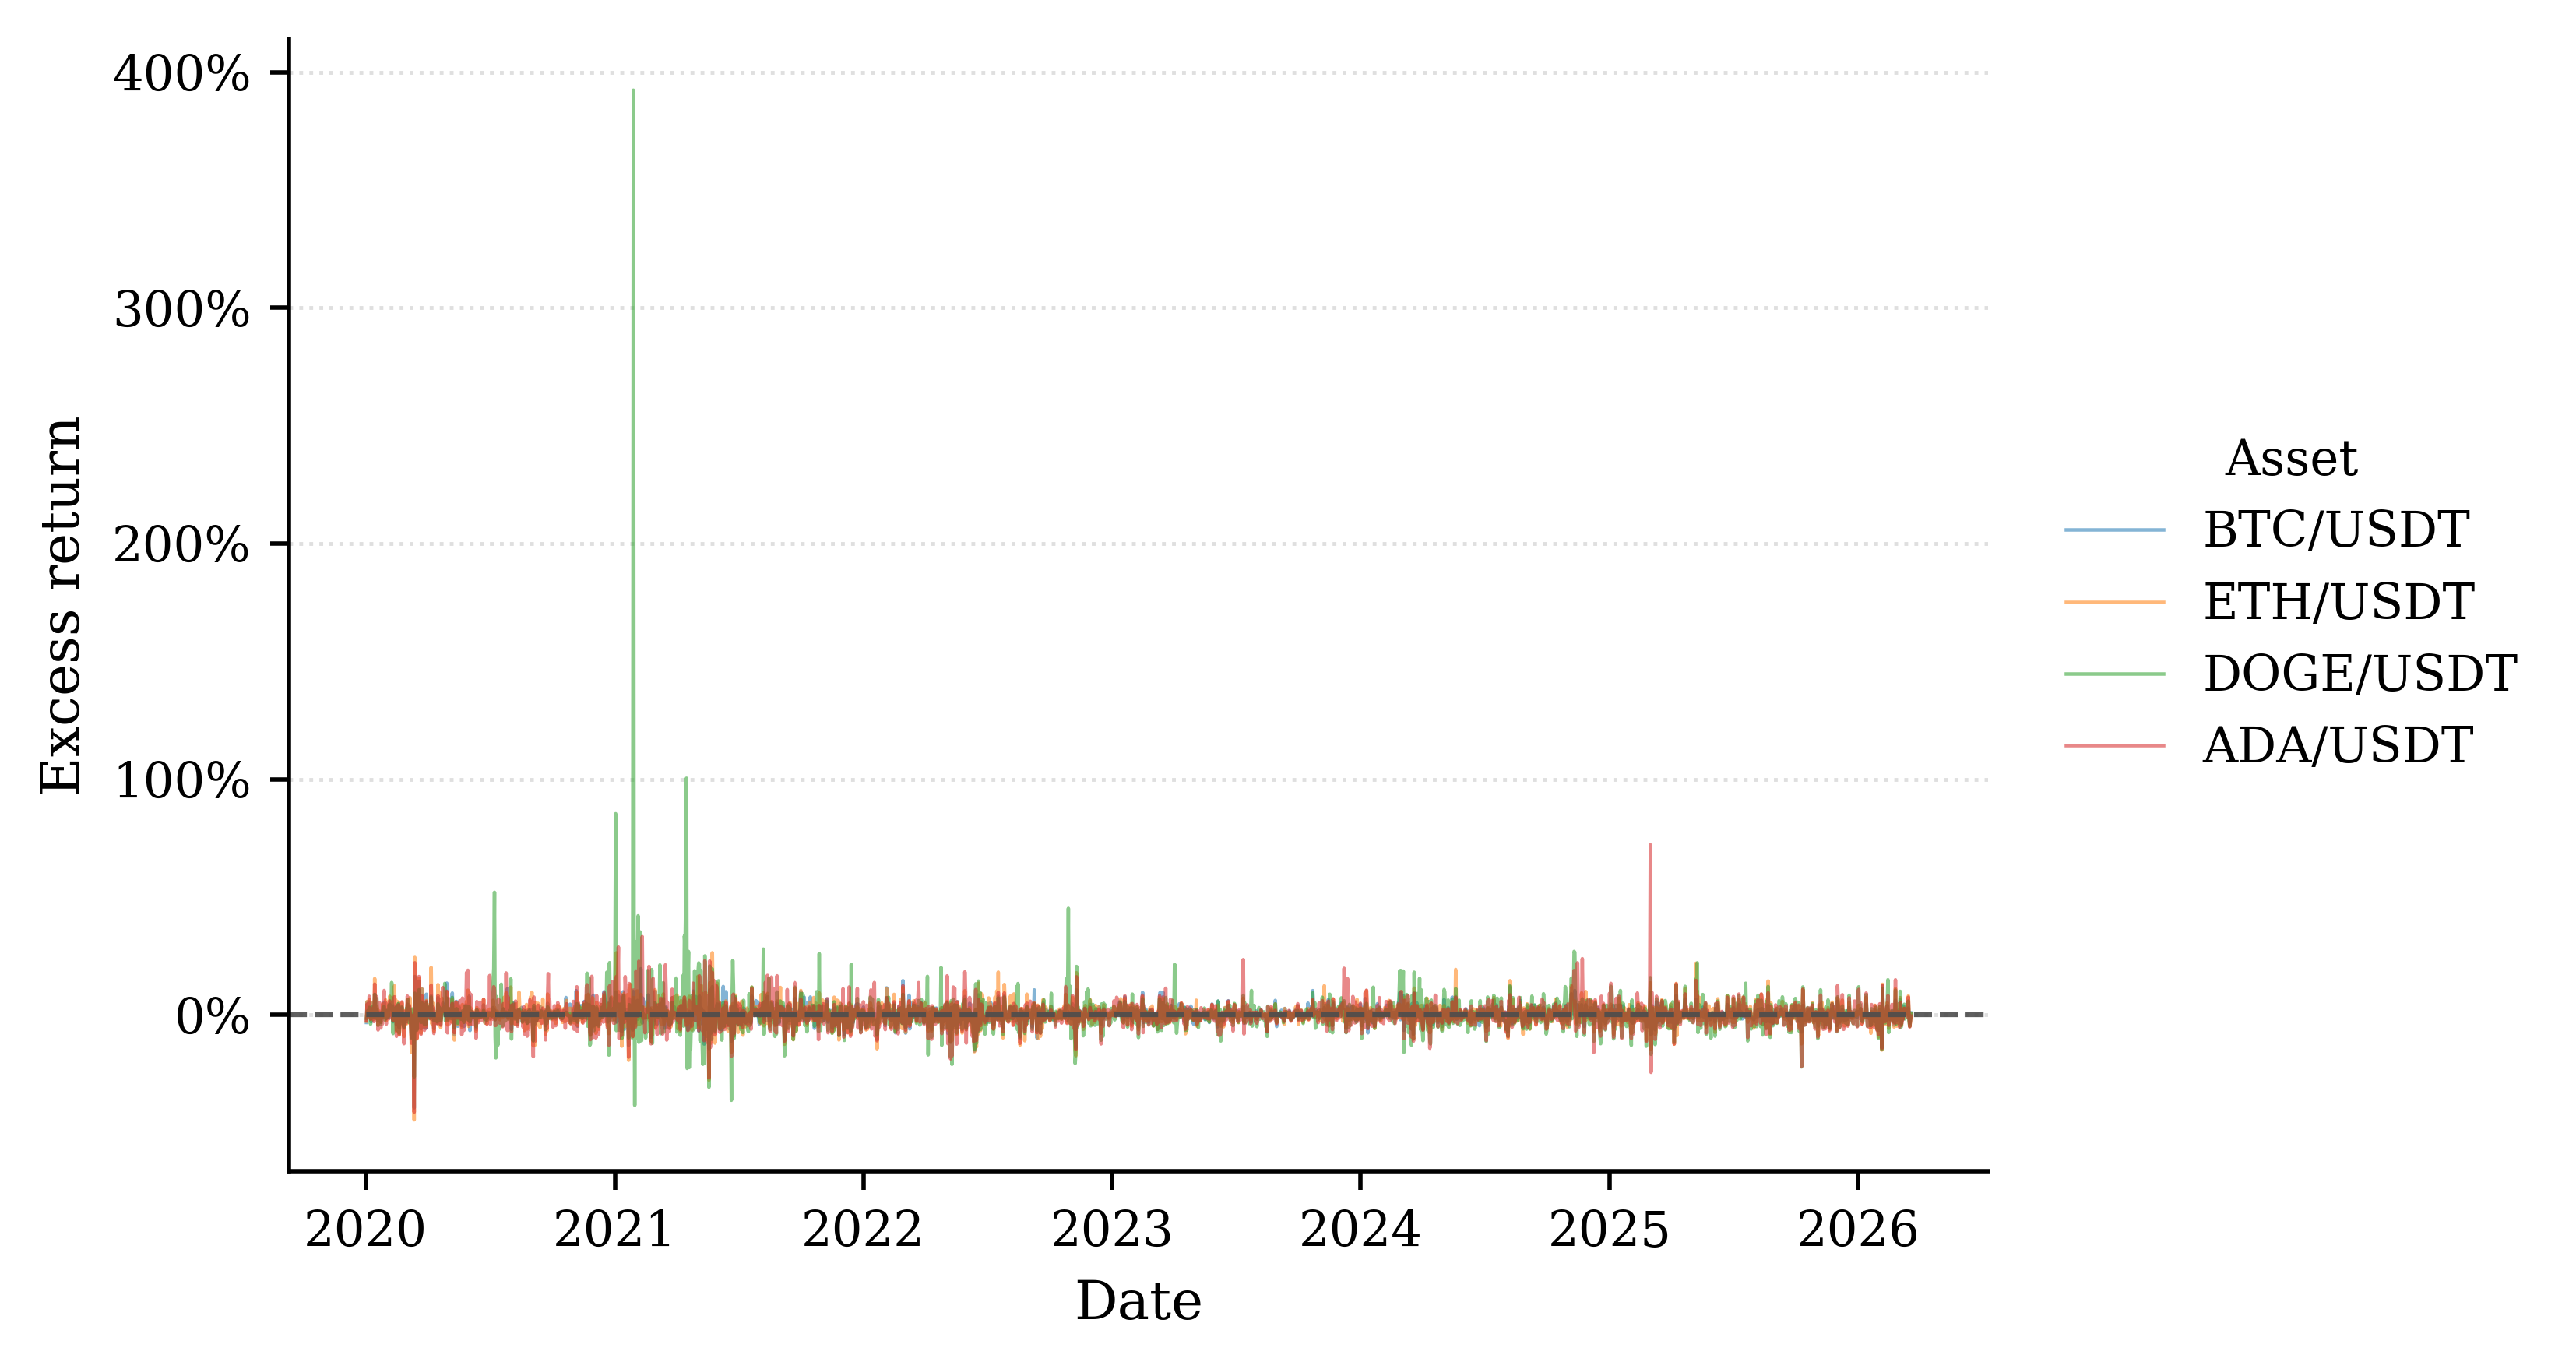

,mean,std,min,max
BTC/USDT,0.001464,0.032319,-0.395078,0.195359
ETH/USDT,0.002113,0.043330,-0.445999,0.263327
DOGE/USDT,0.004596,0.105249,-0.384395,3.924112
ADA/USDT,0.002232,0.053569,-0.413232,0.721407


In [6]:
# Convert FRED DFF (annual %, simple) to an approximate daily return.
rf_daily = ((1 + dff / 100.0) ** (1 / 365.0) - 1).rename("rf_daily")
rf_daily = rf_daily.reindex(pd.date_range(dff.index.min(), dff.index.max(), freq="D", tz="UTC")).ffill()

excess_returns = {}
for symbol in SYMBOLS:
    asset = cleaned_frames[symbol].copy()
    asset_return = asset["close"].pct_change().rename("asset_return")
    aligned_rf = rf_daily.reindex(asset.index).ffill().rename("rf_daily")

    asset["rf_daily"] = aligned_rf
    asset["excess_return"] = asset_return - aligned_rf
    cleaned_frames[symbol] = asset

    excess_returns[symbol] = asset["excess_return"].rename(symbol)

excess_returns_df = pd.concat(excess_returns.values(), axis=1).dropna(how="all")
excess_returns_df.head()

plt.rcParams.update({
    "figure.dpi": 500,
    "savefig.dpi": 500,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

colors = plt.get_cmap("tab10").colors

fig, ax = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)

for i, col in enumerate(excess_returns_df.columns):
    c = colors[i % len(colors)]
    ax.plot(
        excess_returns_df.index,
        excess_returns_df[col],
        color=c,
        linewidth=0.65,
        alpha=0.55,
        label=col,
    )

ax.axhline(0.0, color="0.3", linewidth=0.9, linestyle="--", alpha=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("Excess return")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.4)
ax.grid(False, axis="x")

ax.legend(title="Asset", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "daily_excess_returns.pdf", bbox_inches="tight")
fig.savefig(out_dir / "daily_excess_returns.png", bbox_inches="tight")

plt.show()

excess_returns_df.describe().T[["mean", "std", "min", "max"]]


### Common asset panel

Single datetime index with **MultiIndex** columns `(field, asset)`: `close` and `excess_return` for each symbol. Rows are aligned across assets; `dropna(how="any")` keeps only dates where every column is defined (drops the initial `pct_change` row with no excess return).

In [7]:
close_wide = pd.concat(
    [cleaned_frames[s]["close"] for s in SYMBOLS],
    axis=1,
    keys=pd.MultiIndex.from_product([["close"], SYMBOLS], names=["field", "asset"]),
)
excess_wide = pd.concat(
    [cleaned_frames[s]["excess_return"] for s in SYMBOLS],
    axis=1,
    keys=pd.MultiIndex.from_product([["excess_return"], SYMBOLS], names=["field", "asset"]),
)
asset_panel = pd.concat([close_wide, excess_wide], axis=1).sort_index(axis=1)
# Intersection of valid dates: all assets have close and excess_return
asset_panel = asset_panel.dropna(how="any")

asset_panel.head()

field                        close                             excess_return  \
asset                     ADA/USDT BTC/USDT DOGE/USDT ETH/USDT      ADA/USDT   
timestamp                                                                      
2020-01-02 00:00:00+00:00  0.03269  6965.71  0.001995   127.19     -0.023638   
2020-01-03 00:00:00+00:00  0.03417  7344.96  0.002024   134.35      0.045232   
2020-01-04 00:00:00+00:00  0.03434  7354.11  0.002058   134.20      0.004933   
2020-01-05 00:00:00+00:00  0.03460  7358.75  0.002070   135.37      0.007529   
2020-01-06 00:00:00+00:00  0.03732  7758.00  0.002134   144.15      0.078571   

field                                                    
asset                      BTC/USDT DOGE/USDT  ETH/USDT  
timestamp                                                
2020-01-02 00:00:00+00:00 -0.032697 -0.014564 -0.027418  
2020-01-03 00:00:00+00:00  0.054403  0.014243  0.056252  
2020-01-04 00:00:00+00:00  0.001204  0.016908 -0.001159  
2020-01-05 00:00:00+00:00  0.000589  0.005643  0.008676  
2020-01-06 00:00:00+00:00  0.054213  0.031268  0.064817

### Walk-forward validation split and backtest framework

- **Outer holdout:** last `HOLDOUT_FRAC` of the sample (final test; not used in walk-forward).
- **Walk-forward:** only on the **development** slice; `WF_MODE` is `expanding` (train from dev start) or `rolling` (fixed `TRAIN_BARS` before each validation block).

In [8]:
# --- Outer holdout (20–25% tail) + walk-forward on development sample ---
idx = asset_panel.index.sort_values()
n = len(idx)

HOLDOUT_FRAC = 0.225  # e.g. 0.20–0.25; reserved final test period
holdout_n = max(1, int(round(HOLDOUT_FRAC * n)))
holdout_index = idx[-holdout_n:]
dev_index = idx[:-holdout_n]

# --- Walk-forward config (bars = trading days for 1d data) ---
INITIAL_TRAIN_BARS = 756  # ~3y business days before first validation (tune as needed)
VAL_BARS = 126  # ~6 months per validation block
STEP_BARS = 126  # non-overlapping validation windows
WF_MODE = "expanding"  # "expanding" | "rolling"
TRAIN_BARS = 756  # rolling mode only: fixed training window length

n_dev = len(dev_index)
if INITIAL_TRAIN_BARS + VAL_BARS > n_dev:
    raise ValueError(
        f"Development sample too short for one fold: n_dev={n_dev}, "
        f"need INITIAL_TRAIN_BARS + VAL_BARS = {INITIAL_TRAIN_BARS + VAL_BARS}"
    )
if WF_MODE not in ("expanding", "rolling"):
    raise ValueError('WF_MODE must be "expanding" or "rolling"')
if WF_MODE == "rolling" and TRAIN_BARS > INITIAL_TRAIN_BARS:
    raise ValueError("For rolling folds, set TRAIN_BARS <= INITIAL_TRAIN_BARS so fold 1 has enough history")

fold_rows = []
val_start_pos = INITIAL_TRAIN_BARS
fold_id = 0
while val_start_pos + VAL_BARS <= n_dev:
    fold_id += 1
    val_ix = dev_index[val_start_pos : val_start_pos + VAL_BARS]
    if WF_MODE == "expanding":
        train_ix = dev_index[:val_start_pos]
    else:
        t0 = val_start_pos - TRAIN_BARS
        train_ix = dev_index[t0:val_start_pos]

    fold_rows.append(
        {
            "fold": fold_id,
            "train_start": train_ix.min(),
            "train_end": train_ix.max(),
            "train_bars": len(train_ix),
            "val_start": val_ix.min(),
            "val_end": val_ix.max(),
            "val_bars": len(val_ix),
        }
    )
    val_start_pos += STEP_BARS

wf_folds = pd.DataFrame(fold_rows)
if wf_folds.empty:
    raise ValueError("No walk-forward folds generated; relax INITIAL_TRAIN_BARS, VAL_BARS, or HOLDOUT_FRAC")

# --- Printed date ranges ---
print(f"Full sample: {idx.min().date()} → {idx.max().date()} (n={n})")
print()
print(
    f"Development (train/CV): {dev_index.min().date()} → {dev_index.max().date()} "
    f"(n={len(dev_index)})"
)
print(
    f"Holdout (final test):     {holdout_index.min().date()} → {holdout_index.max().date()} "
    f"(n={len(holdout_index)}, HOLDOUT_FRAC={HOLDOUT_FRAC})"
)
print()
print(f"Walk-forward: WF_MODE={WF_MODE!r}, INITIAL_TRAIN_BARS={INITIAL_TRAIN_BARS}, "
      f"VAL_BARS={VAL_BARS}, STEP_BARS={STEP_BARS}" + (f", TRAIN_BARS={TRAIN_BARS}" if WF_MODE == "rolling" else ""))
print()
display(wf_folds)
print()
assert dev_index.max() < holdout_index.min(), "dev and holdout ranges should not overlap"
print("Sanity check: dev_index.max() < holdout_index.min() — OK")

Full sample: 2020-01-02 → 2026-03-20 (n=2270)

Development (train/CV): 2020-01-02 → 2024-10-25 (n=1759)
Holdout (final test):     2024-10-26 → 2026-03-20 (n=511, HOLDOUT_FRAC=0.225)

Walk-forward: WF_MODE='expanding', INITIAL_TRAIN_BARS=756, VAL_BARS=126, STEP_BARS=126



,fold,train_start,train_end,train_bars,val_start,val_end,val_bars
0,1,2020-01-02 00:00:00+00:00,2022-01-26 00:00:00+00:00,756,2022-01-27 00:00:00+00:00,2022-06-01 00:00:00+00:00,126
1,2,2020-01-02 00:00:00+00:00,2022-06-01 00:00:00+00:00,882,2022-06-02 00:00:00+00:00,2022-10-05 00:00:00+00:00,126
2,3,2020-01-02 00:00:00+00:00,2022-10-05 00:00:00+00:00,1008,2022-10-06 00:00:00+00:00,2023-02-08 00:00:00+00:00,126
3,4,2020-01-02 00:00:00+00:00,2023-02-08 00:00:00+00:00,1134,2023-02-09 00:00:00+00:00,2023-06-14 00:00:00+00:00,126
4,5,2020-01-02 00:00:00+00:00,2023-06-14 00:00:00+00:00,1260,2023-06-15 00:00:00+00:00,2023-10-18 00:00:00+00:00,126
5,6,2020-01-02 00:00:00+00:00,2023-10-18 00:00:00+00:00,1386,2023-10-19 00:00:00+00:00,2024-02-21 00:00:00+00:00,126
6,7,2020-01-02 00:00:00+00:00,2024-02-21 00:00:00+00:00,1512,2024-02-22 00:00:00+00:00,2024-06-26 00:00:00+00:00,126



Sanity check: dev_index.max() < holdout_index.min() — OK


### Strategy 1 – Trend signal construction

Baseline **trend** proxy: distance of spot from a **50-day moving average** of close (`trend_raw = close / ma_50 - 1`). Fifty trading days is a slow trend filter; a longer MA (e.g. 100-day) can be added later.

**Rolling risk:** `vol_20` is the **20-day** rolling standard deviation of **daily simple returns** (`pct_change` on close). It is used both to define a **standardised score for activation** and, in the sizing step, as the **single** inverse-volatility scaling when mapping raw trend to risk weights.

**Standardised score `z` (activation / diagnostics only):** `z = (trend_raw / vol_20).clip(±SIGNAL_CLIP)`. This is **not** used as the dollar-sizing input; it only drives **dead-zone thresholding** (long/short/flat) and plots.

**Clipping:** `z` is clipped to ±`SIGNAL_CLIP` so a single extreme day does not flip activation erratically.

**Dead zone:** positions are **discrete** ({-1, 0, +1}): long if `z > DEAD_ZONE`, short if `z < -DEAD_ZONE`, else flat.

**Parameters** (`MA_WINDOW`, `VOL_WINDOW`, `DEAD_ZONE`, `SIGNAL_CLIP`) are initial choices and can be tuned in walk-forward validation (see the previous section).

Outputs are stored in `signal_panel` with the same MultiIndex column layout as `asset_panel` (`field` × `asset`), aligned to `asset_panel.index`.

In [9]:
# --- Trend signal parameters (initial values; tune in walk-forward) ---
MA_WINDOW = 50
VOL_WINDOW = 20
DEAD_ZONE = 0.25  # dead zone on z = trend_raw / vol_20 (activation only; not used for dollar sizing)
SIGNAL_CLIP = 5.0

close_px = asset_panel["close"]

ma50_list, trend_raw_list, vol_20_list, z_list, trend_position_list = [], [], [], [], []

for s in SYMBOLS:
    c = close_px[s]
    ma_50 = c.rolling(MA_WINDOW, min_periods=MA_WINDOW).mean()
    trend_raw = c / ma_50 - 1
    ret = c.pct_change()
    vol_20 = ret.rolling(VOL_WINDOW, min_periods=VOL_WINDOW).std(ddof=0).replace(0.0, np.nan)
    # z: standardised trend for activation / diagnostics only (single vol division here is not sizing)
    z = (trend_raw / vol_20).clip(-SIGNAL_CLIP, SIGNAL_CLIP)

    tp = np.where(z > DEAD_ZONE, 1.0, np.where(z < -DEAD_ZONE, -1.0, 0.0))
    trend_position = pd.Series(tp, index=c.index, dtype=float).where(z.notna(), np.nan)

    ma50_list.append(ma_50.rename(s))
    trend_raw_list.append(trend_raw.rename(s))
    vol_20_list.append(vol_20.rename(s))
    z_list.append(z.rename(s))
    trend_position_list.append(trend_position.rename(s))

mi = pd.MultiIndex.from_product


def _field_wide(field: str, parts: list[pd.Series]) -> pd.DataFrame:
    return pd.concat(parts, axis=1, keys=mi([[field], SYMBOLS], names=["field", "asset"]))


ma_50_wide = _field_wide("ma_50", ma50_list)
trend_raw_wide = _field_wide("trend_raw", trend_raw_list)
vol_20_wide = _field_wide("vol_20", vol_20_list)
z_wide = _field_wide("z", z_list)
trend_position_wide = _field_wide("trend_position", trend_position_list)

signal_panel = pd.concat(
    [ma_50_wide, trend_raw_wide, vol_20_wide, z_wide, trend_position_wide],
    axis=1,
).sort_index(axis=1)

assert signal_panel.index.equals(asset_panel.index)

signal_panel.head()

field                        ma_50                             trend_position  \
asset                     ADA/USDT BTC/USDT DOGE/USDT ETH/USDT       ADA/USDT   
timestamp                                                                       
2020-01-02 00:00:00+00:00      NaN      NaN       NaN      NaN            NaN   
2020-01-03 00:00:00+00:00      NaN      NaN       NaN      NaN            NaN   
2020-01-04 00:00:00+00:00      NaN      NaN       NaN      NaN            NaN   
2020-01-05 00:00:00+00:00      NaN      NaN       NaN      NaN            NaN   
2020-01-06 00:00:00+00:00      NaN      NaN       NaN      NaN            NaN   

field                                                 trend_raw           \
asset                     BTC/USDT DOGE/USDT ETH/USDT  ADA/USDT BTC/USDT   
timestamp                                                                  
2020-01-02 00:00:00+00:00      NaN       NaN      NaN       NaN      NaN   
2020-01-03 00:00:00+00:00      NaN       NaN      NaN       NaN      NaN   
2020-01-04 00:00:00+00:00      NaN       NaN      NaN       NaN      NaN   
2020-01-05 00:00:00+00:00      NaN       NaN      NaN       NaN      NaN   
2020-01-06 00:00:00+00:00      NaN       NaN      NaN       NaN      NaN   

field                                          vol_20                     \
asset                     DOGE/USDT ETH/USDT ADA/USDT BTC/USDT DOGE/USDT   
timestamp                                                                  
2020-01-02 00:00:00+00:00       NaN      NaN      NaN      NaN       NaN   
2020-01-03 00:00:00+00:00       NaN      NaN      NaN      NaN       NaN   
2020-01-04 00:00:00+00:00       NaN      NaN      NaN      NaN       NaN   
2020-01-05 00:00:00+00:00       NaN      NaN      NaN      NaN       NaN   
2020-01-06 00:00:00+00:00       NaN      NaN      NaN      NaN       NaN   

field                                     z                              
asset                     ETH/USDT ADA/USDT BTC/USDT DOGE/USDT ETH/USDT  
timestamp                                                                
2020-01-02 00:00:00+00:00      NaN      NaN      NaN       NaN      NaN  
2020-01-03 00:00:00+00:00      NaN      NaN      NaN       NaN      NaN  
2020-01-04 00:00:00+00:00      NaN      NaN      NaN       NaN      NaN  
2020-01-05 00:00:00+00:00      NaN      NaN      NaN       NaN      NaN  
2020-01-06 00:00:00+00:00      NaN      NaN      NaN       NaN      NaN

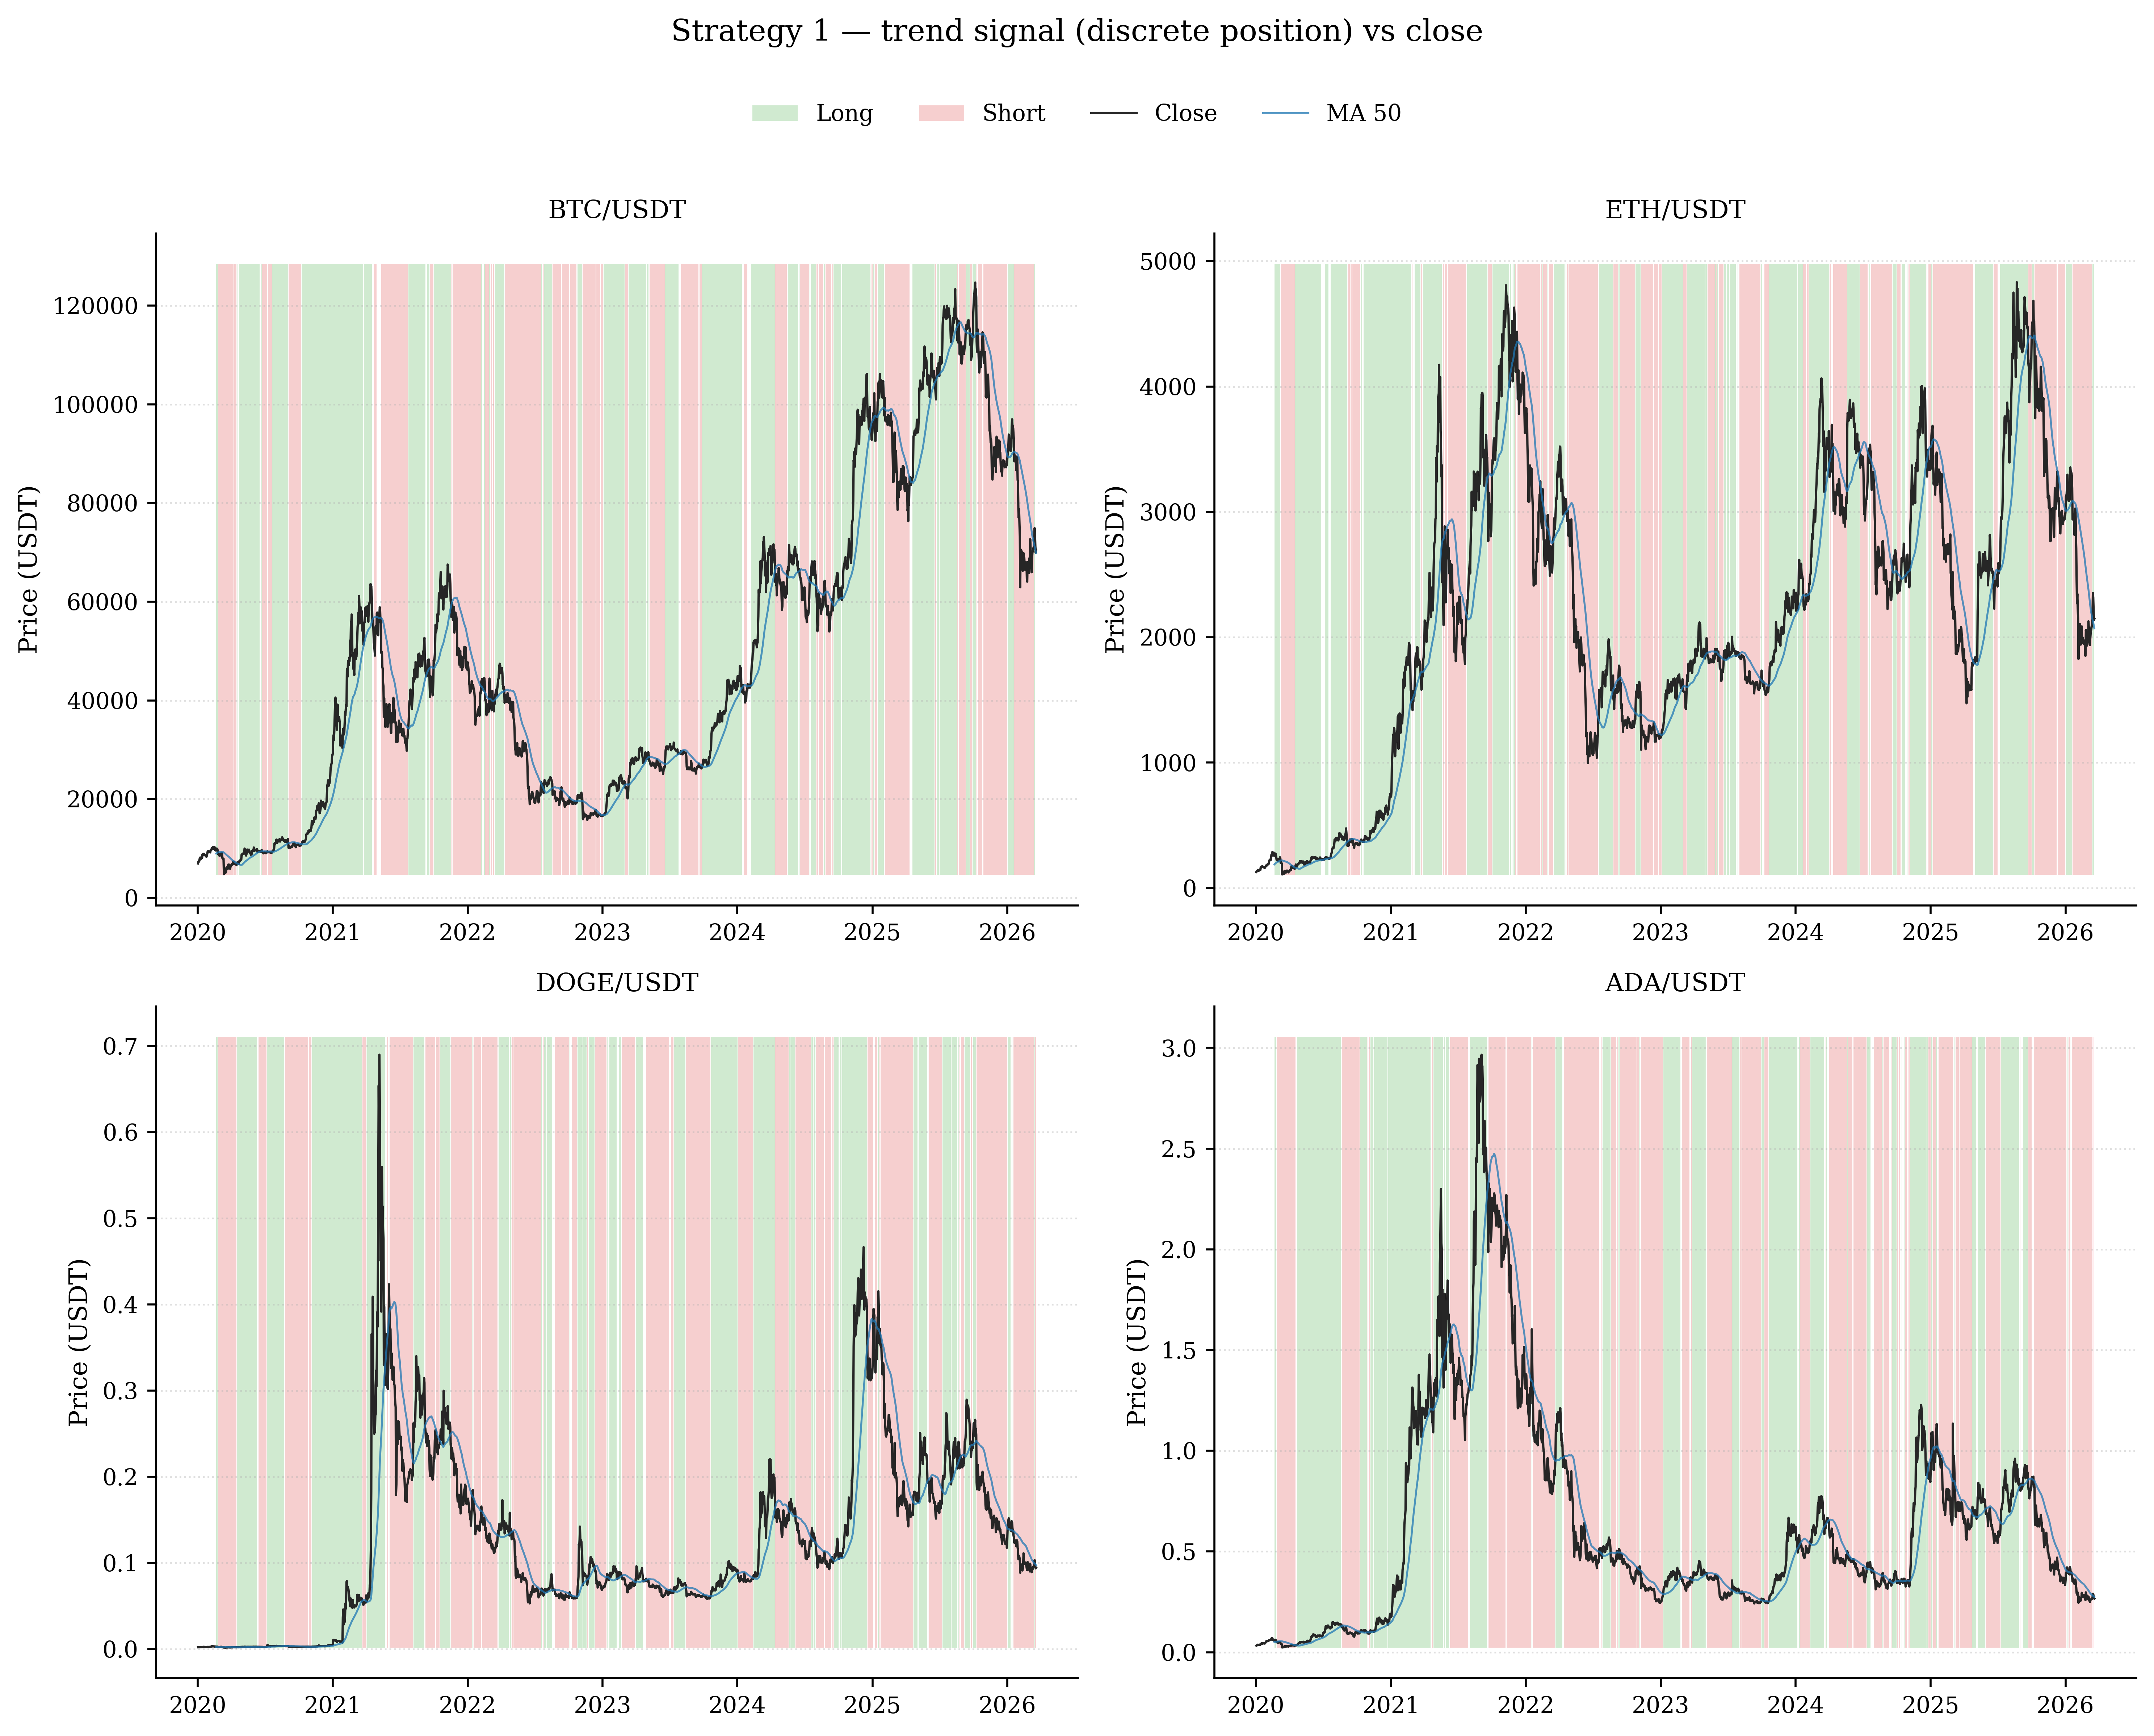

In [10]:
# Price with trend position overlay (green = long, red = short, unshaded = flat)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
axes = axes.ravel()

for ax, s in zip(axes, SYMBOLS):
    close = close_px[s]
    ma_50 = signal_panel["ma_50"][s]
    pos = signal_panel["trend_position"][s]

    idx = close.index
    y_lo = float(close.min()) * 0.97
    y_hi = float(close.max()) * 1.03

    p = pos.to_numpy(dtype=float)
    long_m = np.isfinite(p) & (p == 1.0)
    short_m = np.isfinite(p) & (p == -1.0)

    ax.fill_between(idx, y_lo, y_hi, where=long_m, color="#2ca02c", alpha=0.22, linewidth=0, label="Long")
    ax.fill_between(idx, y_lo, y_hi, where=short_m, color="#d62728", alpha=0.22, linewidth=0, label="Short")
    ax.plot(idx, close, color="0.15", linewidth=0.9, label="Close")
    ax.plot(idx, ma_50, color="tab:blue", linewidth=0.75, alpha=0.75, label="MA 50")

    ax.set_title(s)
    ax.set_ylabel("Price (USDT)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.4)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle("Strategy 1 — trend signal (discrete position) vs close", y=1.06)
plt.tight_layout()

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "trend_signals_vs_price.png", bbox_inches="tight", dpi=150)
fig.savefig(out_dir / "trend_signals_vs_price.pdf", bbox_inches="tight")
plt.show()

### Strategy 1 – Position sizing and exposure mapping

This step turns the **signal** into **tradable dollar exposures** \(\theta_{i,t}\).

**Activation:** `z` is used only for the dead zone (same as `trend_position`). When inactive, weight is zero.

**Raw score:** \(w^{raw}_{i,t} = \text{trend\_raw}_{i,t}\) on active names, else \(0\). We do **not** size with `z` (which already divides by `vol_20` once).

**Single volatility step:** \(w^{risk}_{i,t} = w^{raw}_{i,t} / \text{vol\_20}_{i,t}\) — this is the **only** vol-adjusted sizing step; there is no second division by volatility elsewhere in the pipeline.

**Normalisation:** divide `w_risk` by the **cross-sectional L1 norm** \(\sum_j |w^{risk}_{j,t}|\) (safe when the denominator is 0).

**Gross budget:** fixed **\(G_t = 100{,}000\)**; \(\theta_{i,t} = G_t \tilde{w}_{i,t}\), so \(\sum_i |\theta_{i,t}| = G_t\) whenever at least one asset is active (and \(0\) when all are flat).

**Costs:** transaction costs and P&L enter in a later backtest section; this cell only builds the exposure panel.

Outputs: `exposure_panel` with MultiIndex columns `(field, asset)` for `w_raw`, `w_risk`, `w_tilde`, and `theta`.

In [11]:
# --- Exposures: trend_raw → single vol step (w_risk) → L1 weights → dollar theta ---
# z is for activation / dead-zone only; w_risk = w_raw / vol_20 is the only vol-adjusted sizing step.
GROSS_CAP = 10_000.0  # fixed gross notional budget; sum_i |theta_i| = GROSS_CAP when active (1× V0, no leverage)

tr = signal_panel["trend_raw"]
z = signal_panel["z"]
pos = signal_panel["trend_position"]
vol = signal_panel["vol_20"]

active = (z.abs() > DEAD_ZONE) & z.notna()
w_raw = tr.where(active, 0.0)

sigma = vol.replace(0.0, np.nan)
w_risk = w_raw / sigma

denom = w_risk.abs().sum(axis=1)
denom_safe = denom.replace(0.0, np.nan)
w_tilde = w_risk.div(denom_safe, axis=0).fillna(0.0)

theta = GROSS_CAP * w_tilde


def _field_wide_df(field: str, df: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        [df[s] for s in SYMBOLS],
        axis=1,
        keys=pd.MultiIndex.from_product([[field], SYMBOLS], names=["field", "asset"]),
    )


exposure_panel = pd.concat(
    [
        _field_wide_df("w_raw", w_raw),
        _field_wide_df("w_risk", w_risk),
        _field_wide_df("w_tilde", w_tilde),
        _field_wide_df("theta", theta),
    ],
    axis=1,
).sort_index(axis=1)

assert exposure_panel.index.equals(asset_panel.index)

gross_abs = exposure_panel["theta"].abs().sum(axis=1)
active_rows = denom > 0
print(
    f"Gross |theta| sum: min={gross_abs.min():,.2f}, max={gross_abs.max():,.2f}, "
    f"mean={gross_abs.mean():,.2f}"
)
print(
    f"  (on active rows where denom>0: min={gross_abs[active_rows].min():,.2f}, "
    f"max={gross_abs[active_rows].max():,.2f}, matches GROSS_CAP={GROSS_CAP:,.0f})"
)

# Quick sanity check: sizing chain for a few recent dates (one row per asset)
_check_dates = list(signal_panel.index[-3:])
_sanity = []
for _dt in _check_dates:
    for _s in SYMBOLS:
        _sanity.append(
            {
                "timestamp": _dt,
                "asset": _s,
                "trend_raw": tr.loc[_dt, _s],
                "vol_20": vol.loc[_dt, _s],
                "z": z.loc[_dt, _s],
                "trend_position": pos.loc[_dt, _s],
                "w_raw": w_raw.loc[_dt, _s],
                "w_risk": w_risk.loc[_dt, _s],
                "w_norm": w_tilde.loc[_dt, _s],
                "theta": theta.loc[_dt, _s],
            }
        )
print("Sizing sanity check (last 3 dates × assets):")
display(pd.DataFrame(_sanity))

exposure_panel.tail()

Gross |theta| sum: min=0.00, max=10,000.00, mean=9,784.14
  (on active rows where denom>0: min=10,000.00, max=10,000.00, matches GROSS_CAP=10,000)
Sizing sanity check (last 3 dates × assets):


,timestamp,asset,trend_raw,vol_20,z,trend_position,w_raw,w_risk,w_norm,theta
0,2026-03-18 00:00:00+00:00,BTC/USDT,0.010004,0.027022,0.370215,1.0,0.010004,0.370215,0.128055,1280.548296
1,2026-03-18 00:00:00+00:00,ETH/USDT,0.048324,0.035618,1.356723,1.0,0.048324,1.356723,0.469282,4692.818075
2,2026-03-18 00:00:00+00:00,DOGE/USDT,-0.030034,0.036983,-0.812103,-1.0,-0.030034,-0.812103,-0.280901,-2809.013598
3,2026-03-18 00:00:00+00:00,ADA/USDT,-0.011343,0.032223,-0.352022,-1.0,-0.011343,-0.352022,-0.121762,-1217.620030
4,2026-03-19 00:00:00+00:00,BTC/USDT,-0.003185,0.026776,-0.118957,0.0,0.000000,0.000000,0.000000,0.000000
5,2026-03-19 00:00:00+00:00,ETH/USDT,0.025643,0.034451,0.744331,1.0,0.025643,0.744331,0.265703,2657.034986
6,2026-03-19 00:00:00+00:00,DOGE/USDT,-0.041406,0.036237,-1.142632,-1.0,-0.041406,-1.142632,-0.407885,-4078.849458
7,2026-03-19 00:00:00+00:00,ADA/USDT,-0.029144,0.031872,-0.914396,-1.0,-0.029144,-0.914396,-0.326412,-3264.115556
8,2026-03-20 00:00:00+00:00,BTC/USDT,0.009161,0.026628,0.344021,1.0,0.009161,0.344021,0.108481,1084.807580
9,2026-03-20 00:00:00+00:00,ETH/USDT,0.036404,0.034337,1.060199,1.0,0.036404,1.060199,0.334314,3343.142139


field                            theta                                         \
asset                         ADA/USDT     BTC/USDT    DOGE/USDT     ETH/USDT   
timestamp                                                                       
2026-03-16 00:00:00+00:00  1301.011188  3010.357039  1462.889782  4225.741991   
2026-03-17 00:00:00+00:00  1937.728146  2775.360372   616.167109  4670.744373   
2026-03-18 00:00:00+00:00 -1217.620030  1280.548296 -2809.013598  4692.818075   
2026-03-19 00:00:00+00:00 -3264.115556     0.000000 -4078.849458  2657.034986   
2026-03-20 00:00:00+00:00 -2921.243417  1084.807580 -2650.806864  3343.142139   

field                         w_raw                                  w_risk  \
asset                      ADA/USDT  BTC/USDT DOGE/USDT  ETH/USDT  ADA/USDT   
timestamp                                                                     
2026-03-16 00:00:00+00:00  0.035892  0.051904  0.037952  0.104397  0.798328   
2026-03-17 00:00:00+00:00  0.035911  0.042432  0.013375  0.093992  1.155647   
2026-03-18 00:00:00+00:00 -0.011343  0.010004 -0.030034  0.048324 -0.352022   
2026-03-19 00:00:00+00:00 -0.029144  0.000000 -0.041406  0.025643 -0.914396   
2026-03-20 00:00:00+00:00 -0.029392  0.009161 -0.030458  0.036404 -0.926404   

field                                                     w_tilde            \
asset                      BTC/USDT DOGE/USDT  ETH/USDT  ADA/USDT  BTC/USDT   
timestamp                                                                     
2026-03-16 00:00:00+00:00  1.847219  0.897660  2.593006  0.130101  0.301036   
2026-03-17 00:00:00+00:00  1.655205  0.367478  2.785598  0.193773  0.277536   
2026-03-18 00:00:00+00:00  0.370215 -0.812103  1.356723 -0.121762  0.128055   
2026-03-19 00:00:00+00:00  0.000000 -1.142632  0.744331 -0.326412  0.000000   
2026-03-20 00:00:00+00:00  0.344021 -0.840641  1.060199 -0.292124  0.108481   

field                                          
asset                     DOGE/USDT  ETH/USDT  
timestamp                                      
2026-03-16 00:00:00+00:00  0.146289  0.422574  
2026-03-17 00:00:00+00:00  0.061617  0.467074  
2026-03-18 00:00:00+00:00 -0.280901  0.469282  
2026-03-19 00:00:00+00:00 -0.407885  0.265703  
2026-03-20 00:00:00+00:00 -0.265081  0.334314

### Strategy 1 – Backtest engine (gross PnL first)

Coursework P&L identity: \(\Delta V_t = \sum_i \theta_{i,t-1}\, r_{i,t} - \mathrm{Cost}_t\). This section implements the **gross** term only (no `Cost_t` yet).

**Lag:** positions are **executed** with a one-bar lag: `theta_exec = theta.shift(1)`, so the return \(r_{i,t}\) is multiplied by **yesterday’s** dollar exposure \(\theta_{i,t-1}\) (no lookahead).

**Returns:** by default we use **simple returns** from `close` (`pct_change`). At a daily horizon the risk-free rate is small relative to typical crypto moves; you can switch to **excess returns** in code for a stricter alpha interpretation.

**Per asset:** \(\text{gross\_pnl}_{i,t} = \theta_{i,t-1}\, r_{i,t}\). **Portfolio:** \(\text{gross\_pnl}_t = \sum_i \text{gross\_pnl}_{i,t}\).

**Capital:** \(V_0 = 10{,}000\) USDT. **Cumulative gross PnL** and **gross portfolio value** \(V_t = V_0 + \sum_{s \le t} \text{gross\_pnl}_s\). Report **total PnL (USDT)** and **percentage return on \(V_0\)**.

**Diagnostics:** gross exposure \(\sum_i |\theta_{i,t-1}|\), **net** exposure \(\sum_i \theta_{i,t-1}\), **active asset count**, and **`gross_pnl_contrib`** (wide) for attribution.

In [12]:
# --- Gross backtest: lagged theta × returns (costs not yet applied) ---
BACKTEST_USE_EXCESS = False  # True → use asset_panel["excess_return"] instead of simple returns

theta = exposure_panel["theta"]
theta_exec = theta.shift(1)

if BACKTEST_USE_EXCESS:
    r = asset_panel["excess_return"]
else:
    r = asset_panel["close"].pct_change()

assert theta_exec.index.equals(asset_panel.index)
assert r.index.equals(asset_panel.index)

gross_pnl_contrib = theta_exec.mul(r)
gross_pnl = gross_pnl_contrib.sum(axis=1).fillna(0.0)

V0 = 10_000.0
cumulative_gross_pnl = gross_pnl.cumsum()
gross_portfolio_value = V0 + cumulative_gross_pnl
pct_return_on_capital = cumulative_gross_pnl / V0

gross_exposure_t = theta_exec.abs().sum(axis=1)
net_exposure_t = theta_exec.sum(axis=1)
n_active_t = (theta_exec.fillna(0.0) != 0.0).sum(axis=1)

backtest_summary = pd.DataFrame(
    {
        "gross_pnl": gross_pnl,
        "cumulative_gross_pnl": cumulative_gross_pnl,
        "gross_portfolio_value": gross_portfolio_value,
        "pct_return_on_capital": pct_return_on_capital,
        "gross_exposure": gross_exposure_t,
        "net_exposure": net_exposure_t,
        "n_active": n_active_t,
    }
)

total_pnl_usdt = cumulative_gross_pnl.iloc[-1]
total_pct = pct_return_on_capital.iloc[-1]
print(f"Total gross PnL (USDT): {total_pnl_usdt:,.2f}")
print(f"Total return on V0 ({V0:,.0f} USDT): {total_pct * 100:.2f}%")
print(f"Final gross portfolio value (USDT): {gross_portfolio_value.iloc[-1]:,.2f}")

display(backtest_summary.head())
gross_pnl_contrib.head()

Total gross PnL (USDT): 64,192.90
Total return on V0 (10,000 USDT): 641.93%
Final gross portfolio value (USDT): 74,192.90


,gross_pnl,cumulative_gross_pnl,gross_portfolio_value,pct_return_on_capital,gross_exposure,net_exposure,n_active
timestamp,,,,,,,
2020-01-02 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-03 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-04 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-05 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-06 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0


asset,ADA/USDT,BTC/USDT,DOGE/USDT,ETH/USDT
timestamp,,,,
2020-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN
2020-01-03 00:00:00+00:00,0.0,0.0,0.0,0.0
2020-01-04 00:00:00+00:00,0.0,0.0,0.0,-0.0
2020-01-05 00:00:00+00:00,0.0,0.0,0.0,0.0
2020-01-06 00:00:00+00:00,0.0,0.0,0.0,0.0


### Strategy 1 – Costs, net PnL, and turnover (Abdi–Ranaldo spread)

**Spread model:** we reuse the **Abdi–Ranaldo (2017)** estimator from [`strategy_final.ipynb`](strategy_final.ipynb) (`abdi_ranaldo_spread` on daily `high`, `low`, `close`). On **daily** crypto data the **Roll (1984)** model is often **invalid** when serial covariance of price changes is non-negative; AR remains usable as a **relative** spread proxy.

**Half-spread and lag:** as in `strategy_final`, execution uses **`0.5 × spread` lagged one day** (`shift(1)`), so the cost rate on day \(t\) does not react to the same bar’s quote.

**Cost rate in USDT:** let **`half_spread_frac_{i,t} = 0.5 · AR_{i,t}`** — the Abdi–Ranaldo estimator is already dimensionless (derived from log-price ratios), so no division by close is applied. **Per-asset** cost = half-spread × **dollar** turnover in that name; **total** **`cost_t`** is the sum across \(i\). This matches \(\mathrm{Cost}_t = \sum_i s_{i,t} |\Delta\theta_i|\) with **\(s_{i,t}\)** as the dimensionless half-spread.

**Rebalancing (coursework):** \(\mathrm{Cost}_t\) is tied to turnover \(\sum_i |\theta_{i,t} - \theta_{i,t-1}(1+r_{i,t-1})|\); we compute **`carried`**, **`turnover`**, then multiply by the **per-asset lagged** half-spread fraction.

**Net PnL:** \(\Delta V_t^{\mathrm{net}} = \text{gross\_pnl}_t - \mathrm{Cost}_t\), then cumulative net PnL and **`net_portfolio_value`** from **`V0`**.

Total gross PnL (USDT): 64,192.90
Total costs (USDT):     38,694.24
Total net PnL (USDT):   25,498.67


,gross_pnl,cost,net_pnl,cumulative_net_pnl,net_portfolio_value,turnover
timestamp,,,,,,
2020-01-02 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-03 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-04 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-05 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-06 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0


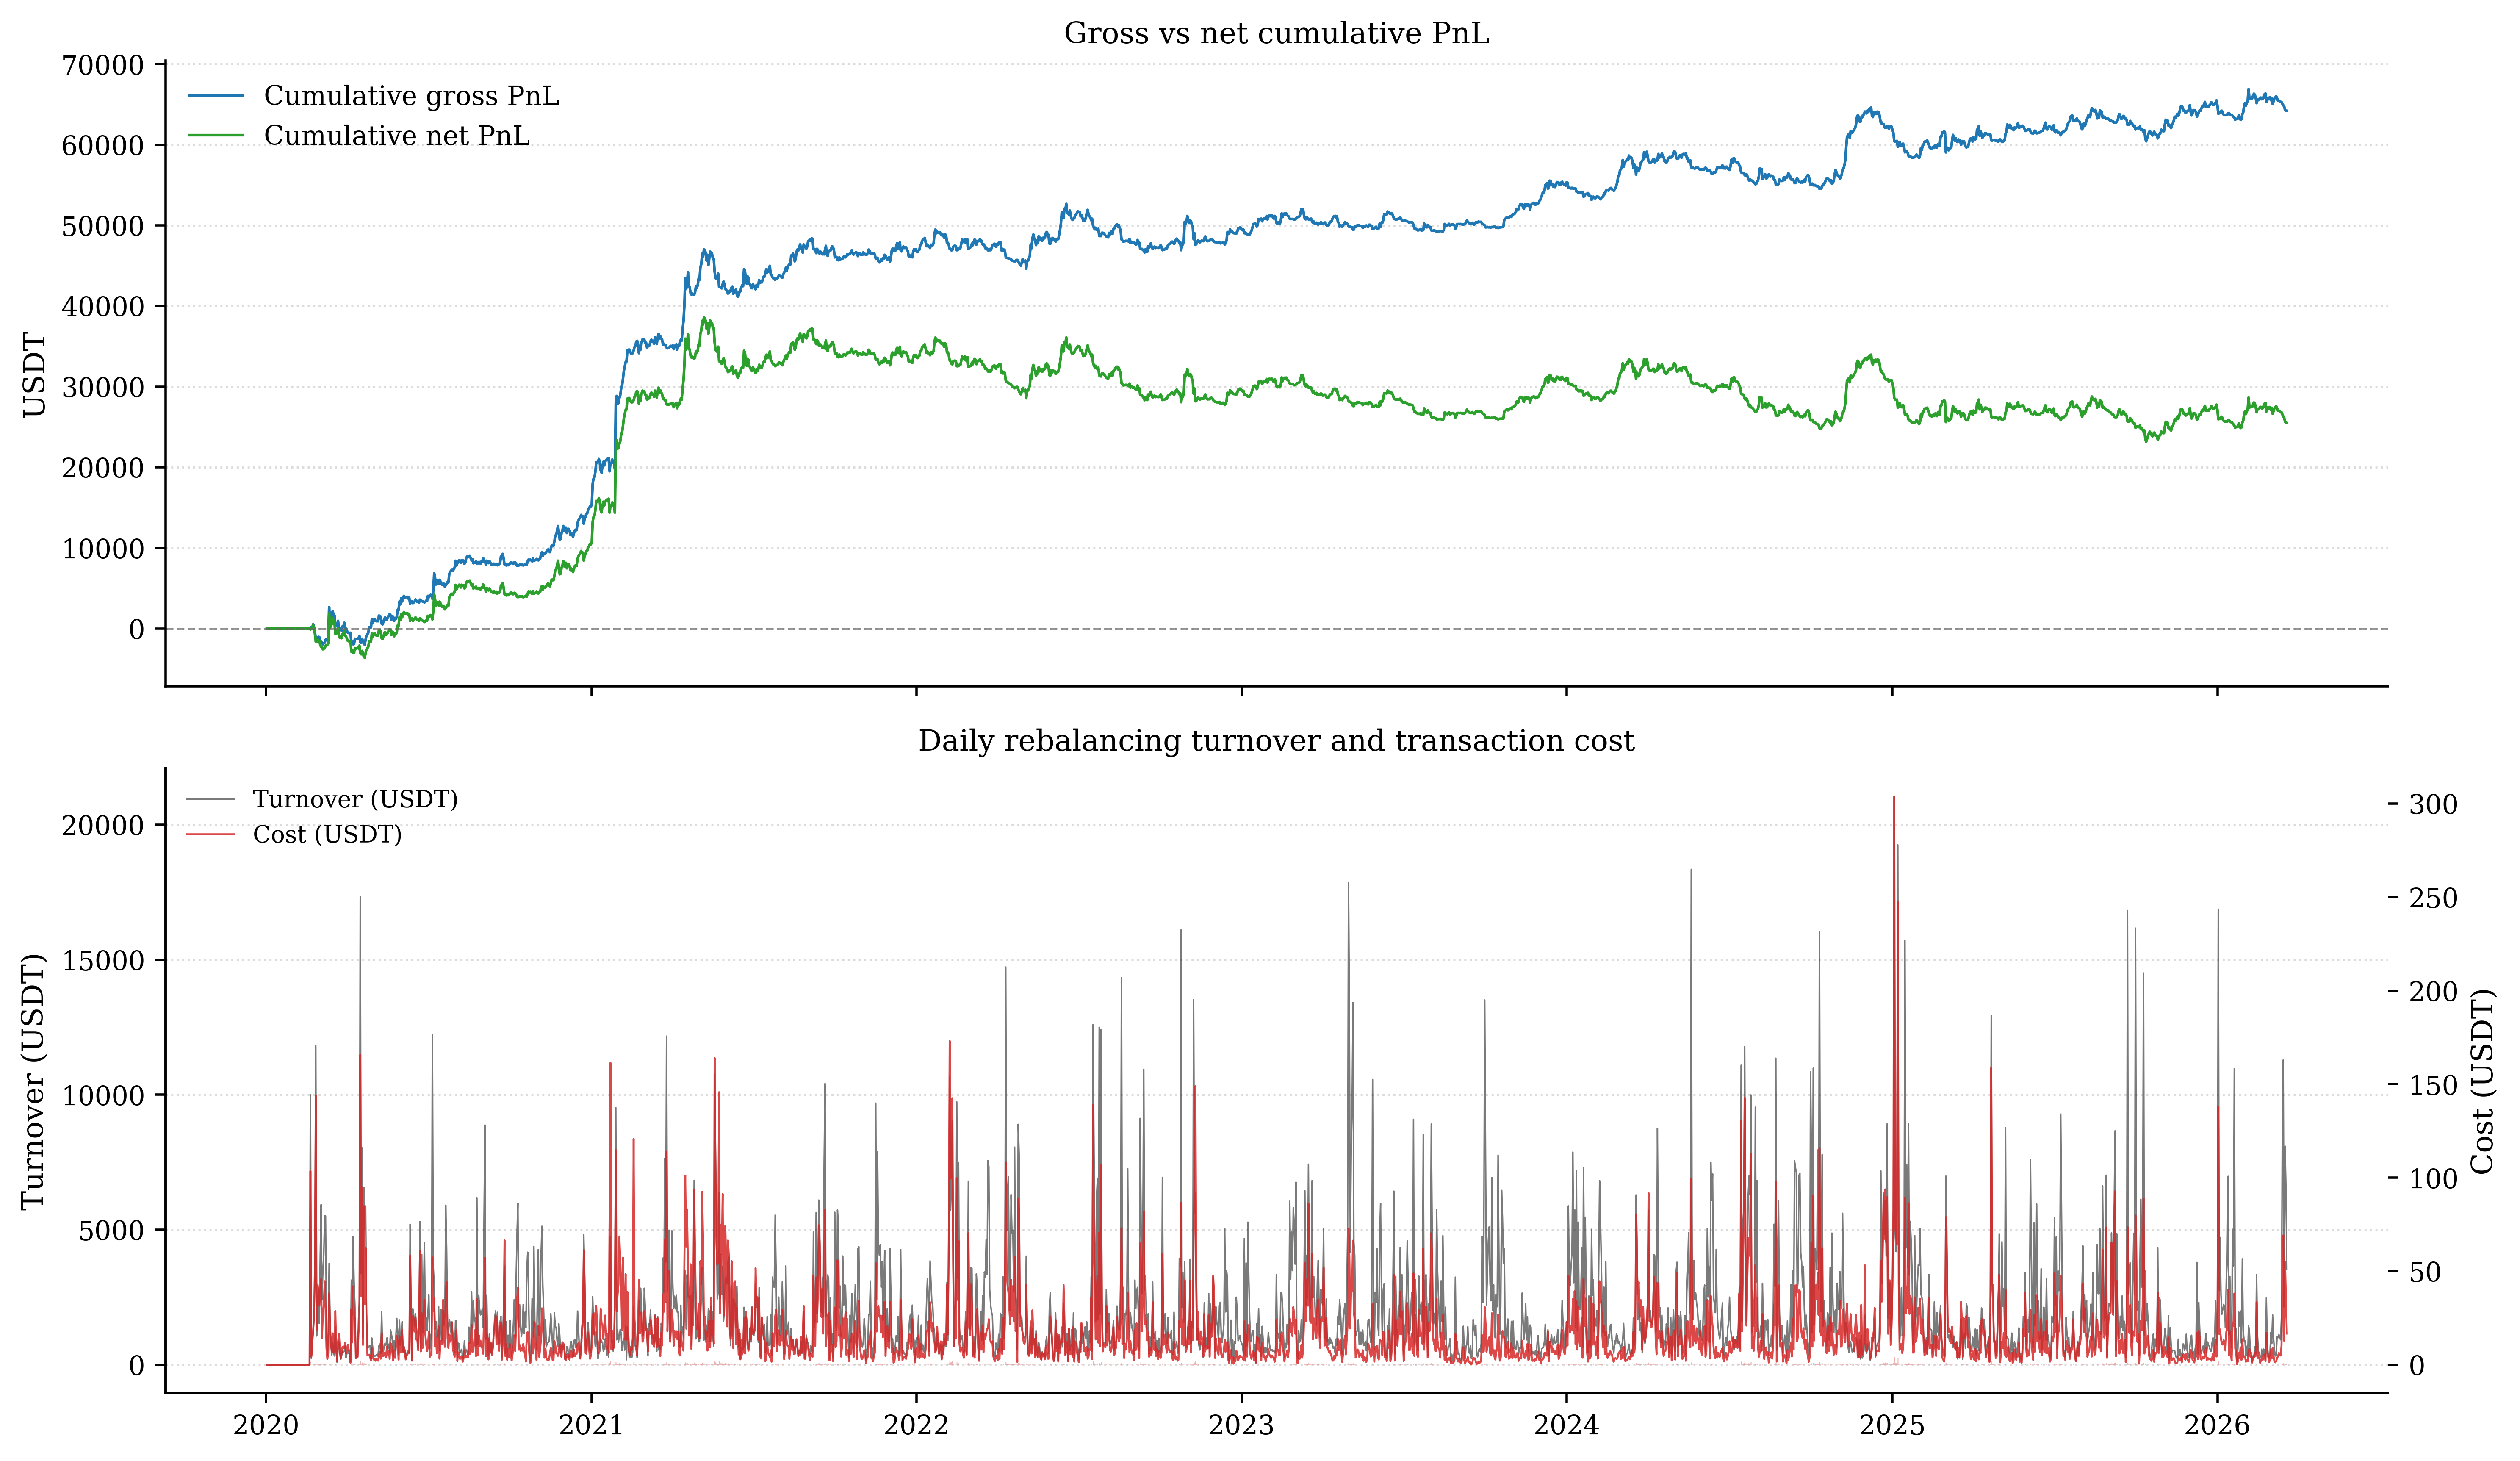

In [13]:
ar_by_asset = {}
for s in SYMBOLS:
    ar_by_asset[s] = abdi_ranaldo_spread(cleaned_frames[s]).reindex(asset_panel.index)

ar_spread_wide = pd.concat([ar_by_asset[s] for s in SYMBOLS], axis=1, keys=SYMBOLS)
close_px = asset_panel["close"]

# Half-spread fraction (lagged): cost per USDT traded in that name
half_spread = 0.5 * ar_spread_wide
half_spread_frac = half_spread.shift(1).replace([np.inf, -np.inf], np.nan)

# Rebalance-aware execution: this Strategy 1 section still rebalances daily.

theta_tgt = exposure_panel["theta"]
theta_input = theta_tgt.copy()
theta_input.attrs["theta_target"] = theta_tgt.copy()
theta_input.attrs["rebalance_mask"] = pd.Series(True, index=theta_tgt.index, name="is_rebalance")
theta_input.attrs["rebalance_every"] = 1

out_strategy1 = run_net_backtest(
    asset_panel,
    theta_input,
    SYMBOLS,
    half_spread_frac,
    backtest_use_excess=BACKTEST_USE_EXCESS,
    v0=V0,
)

theta_exec = out_strategy1["theta_exec"]
carried = out_strategy1["carried"]
delta_theta_exec = out_strategy1["delta_theta_exec"]
gross_pnl = out_strategy1["gross_pnl"]
cumulative_gross_pnl = gross_pnl.cumsum()
turnover = out_strategy1["turnover"]
cost_t = out_strategy1["cost_t"]
net_pnl = out_strategy1["net_pnl"]
cumulative_net_pnl = net_pnl.cumsum()
net_portfolio_value = out_strategy1["net_portfolio_value"]

net_backtest_summary = pd.DataFrame(
    {
        "gross_pnl": gross_pnl,
        "cost": cost_t,
        "net_pnl": net_pnl,
        "cumulative_net_pnl": cumulative_net_pnl,
        "net_portfolio_value": net_portfolio_value,
        "turnover": turnover,
    }
)

print(f"Total gross PnL (USDT): {cumulative_gross_pnl.iloc[-1]:,.2f}")
print(f"Total costs (USDT):     {cost_t.sum():,.2f}")
print(f"Total net PnL (USDT):   {cumulative_net_pnl.iloc[-1]:,.2f}")
display(net_backtest_summary.head())

# --- Net vs gross + cost + turnover (saved figures) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(net_backtest_summary.index, cumulative_gross_pnl, color="tab:blue", linewidth=0.9, label="Cumulative gross PnL")
axes[0].plot(net_backtest_summary.index, cumulative_net_pnl, color="tab:green", linewidth=0.9, label="Cumulative net PnL")
axes[0].axhline(0.0, color="0.4", linewidth=0.7, linestyle="--", alpha=0.7)
axes[0].set_ylabel("USDT")
axes[0].legend(loc="upper left", frameon=False)
axes[0].set_title("Gross vs net cumulative PnL")
axes[0].grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)

axes[1].fill_between(net_backtest_summary.index, 0.0, cost_t, step="mid", color="tab:red", alpha=0.35, linewidth=0)
axes[1].plot(net_backtest_summary.index, turnover, color="0.2", linewidth=0.5, alpha=0.65, label="Turnover (USDT)")
ax_r = axes[1].twinx()
ax_r.plot(net_backtest_summary.index, cost_t, color="tab:red", linewidth=0.65, alpha=0.85, label="Cost (USDT)")
axes[1].set_ylabel("Turnover (USDT)")
ax_r.set_ylabel("Cost (USDT)")
axes[1].set_title("Daily rebalancing turnover and transaction cost")
lines, labels = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax_r.legend(lines + lines2, labels + labels2, loc="upper left", frameon=False, fontsize=8)
axes[1].grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "net_vs_gross_cost_turnover.png", bbox_inches="tight", dpi=150)
fig.savefig(out_dir / "net_vs_gross_cost_turnover.pdf", bbox_inches="tight")
plt.show()

### Strategy 1 – Performance metrics and IS / OOS reporting

**Returns:** daily **net equity return** \(r_t = V_t / V_{t-1} - 1\) from **`net_portfolio_value`** (alternatively `net_pnl_t / V_{t-1}\); document if you switch).

**Ratios (annualised, \(\sqrt{252}\)):** **Sharpe** (full-sample std), **Sortino** (downside deviation vs 0), **Calmar** (annualised net return / |max drawdown| on net equity).

**Risk:** **max drawdown** on **`net_portfolio_value`**.

**Holding horizon:** mean length of **contiguous** days with **any** executed exposure (`\(\sum_i |\theta_{i,t-1}| > 0\)`).

**IS / OOS:** **in-sample** = dates in **`dev_index`**; **out-of-sample** = **`holdout_index`** (same split as walk-forward). Metrics computed on each subsample’s **aligned** returns and equity path.

In [14]:
# --- Performance metrics (net) + IS / OOS ---
TRADING_DAYS = 252

r_net_daily = net_portfolio_value.pct_change().replace([np.inf, -np.inf], np.nan)


def max_dd(equity: pd.Series) -> float:
    eq = equity.dropna()
    if eq.empty:
        return np.nan
    peak = eq.cummax()
    dd = (eq - peak) / peak.replace(0.0, np.nan)
    return float(dd.min())


def sharpe_ratio(returns: pd.Series, trading_days: int = TRADING_DAYS) -> float:
    r = returns.dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / r.std(ddof=1))


def sortino_ratio(returns: pd.Series, mar: float = 0.0) -> float:
    r = returns.dropna()
    downside = r[r < mar] - mar
    if len(r) < 2 or len(downside) == 0:
        return np.nan
    ds = downside.std(ddof=0)
    if ds == 0 or np.isnan(ds):
        return np.nan
    return float(np.sqrt(TRADING_DAYS) * (r.mean() - mar) / ds)


def calmar_ratio(returns: pd.Series, equity: pd.Series) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return np.nan
    if equity.iloc[-1] <= 0 or equity.iloc[0] <= 0:
        return np.nan
    ann = (equity.iloc[-1] / equity.iloc[0]) ** (TRADING_DAYS / len(r)) - 1.0
    mdd = max_dd(equity)
    if mdd is None or mdd == 0 or np.isnan(mdd):
        return np.nan
    return float(ann / abs(mdd))


def mean_holding_horizon_per_asset(theta_exec: pd.DataFrame) -> float:
    durations = []
    for col in theta_exec.columns:
        sign = np.sign(theta_exec[col].fillna(0))
        flips = (sign != sign.shift()).cumsum()
        for _, grp in sign.groupby(flips):
            if grp.iloc[0] != 0:
                durations.append(len(grp))
    return np.mean(durations) if durations else np.nan


def perf_block(mask: pd.Index, label: str) -> dict:
    m = net_portfolio_value.index.isin(mask)
    eq = net_portfolio_value[m]
    r = r_net_daily[m]
    total_ret = float(eq.iloc[-1] / eq.iloc[0] - 1.0) if len(eq) > 1 else np.nan
    ann_ret = float((eq.iloc[-1] / eq.iloc[0]) ** (TRADING_DAYS / len(r.dropna())) - 1.0) if (len(r.dropna()) > 1 and eq.iloc[0] > 0 and eq.iloc[-1] > 0) else np.nan
    return {
        "sample": label,
        "n_days": int(m.sum()),
        "total_return": total_ret,
        "ann_return": ann_ret,
        "sharpe": sharpe_ratio(r),
        "sortino": sortino_ratio(r),
        "calmar": calmar_ratio(r, eq),
        "max_drawdown": max_dd(eq),
        "total_net_pnl": float(net_pnl.loc[m].sum()) if m.any() else np.nan,
    }


horizon_days = mean_holding_horizon_per_asset(theta_exec)

perf_full = {
    "sample": "full",
    "n_days": len(net_portfolio_value),
    "total_return": float(net_portfolio_value.iloc[-1] / V0 - 1.0),
    "ann_return": float((net_portfolio_value.iloc[-1] / V0) ** (TRADING_DAYS / len(r_net_daily.dropna())) - 1.0) if net_portfolio_value.iloc[-1] > 0 else np.nan,
    "sharpe": sharpe_ratio(r_net_daily),
    "sortino": sortino_ratio(r_net_daily),
    "calmar": calmar_ratio(r_net_daily, net_portfolio_value),
    "max_drawdown": max_dd(net_portfolio_value),
    "total_net_pnl": float(cumulative_net_pnl.iloc[-1]),
    "pct_return_on_V0": float(cumulative_net_pnl.iloc[-1] / V0),
    "mean_holding_horizon_days": horizon_days,
}

perf_is = perf_block(dev_index, "IS (development)")
perf_oos = perf_block(holdout_index, "OOS (holdout)")

perf_df = pd.DataFrame([perf_full, perf_is, perf_oos])

display(perf_df.T)

print(f"Mean holding horizon (days, per-asset directional position): {horizon_days:.2f}")

,0,1,2
sample,full,IS (development),OOS (holdout)
n_days,2270,1759,511
total_return,2.549867,2.520871,0.005272
ann_return,0.151086,0.197731,0.002596
sharpe,0.587874,0.673585,0.105332
sortino,0.882527,1.022142,0.139953
calmar,0.327792,0.428993,0.010571
max_drawdown,-0.46092,-0.46092,-0.24562
total_net_pnl,25498.666296,25208.708808,289.957488
pct_return_on_V0,2.549867,NaN,NaN


Mean holding horizon (days, per-asset directional position): 17.78


### Strategy 1 – Walk-forward parameter search (development sample)

We **tune** signal and sizing parameters **only** on the **development** period (`dev_index`), using the **pre-defined walk-forward folds** (`wf_folds`). Each **validation** window is **out-of-sample** relative to the expanding training calendar before it, but **in-sample** relative to the final **holdout** tail (which never enters this grid).

**Grid (illustrative):** `MA_WINDOW` ∈ {50, 75, 100}, `VOL_WINDOW` ∈ {20, 30}, dead-zone threshold ∈ {0.25, 0.5}, **rebalance** every **1** or **3** trading days (forward-filled dollar exposures between rebalance dates).

**Per fold** on **net** equity we record validation **Sharpe**, **total return**, **max drawdown**, and **mean turnover**. **Ranking:** primary score = **mean validation Sharpe** minus **`STABILITY_PENALTY ×` std(Sharpe)** across folds (reward stable performance, not a single lucky window).

Implementation uses the in-notebook helper functions (Cell 2) so the pipeline matches the notebook with rebalance-aware execution, turnover, and Abdi–Ranaldo transaction costs.



In [15]:
STABILITY_PENALTY = 0.1
SIGNAL_CLIP_WF = 5.0
GROSS_CAP_WF = GROSS_CAP
V0_WF = V0

asset_panel_dev = asset_panel.loc[dev_index].copy()
half_spread_frac_dev = compute_half_spread_frac(asset_panel_dev, cleaned_frames, SYMBOLS)

MA_GRID = [50, 75, 100]
VOL_GRID = [20, 30]
THRESH_GRID = [0.25, 0.5]
REBAL_GRID = [1, 3]

wf_rows = []
for ma_w, vol_w, dz, rebal in product(MA_GRID, VOL_GRID, THRESH_GRID, REBAL_GRID):
    theta_p = build_signal_and_theta(
        asset_panel_dev,
        SYMBOLS,
        ma_window=ma_w,
        vol_window=vol_w,
        dead_zone=dz,
        signal_clip=SIGNAL_CLIP_WF,
        gross_cap=GROSS_CAP_WF,
        rebalance_every=rebal,
    )
    out_p = run_net_backtest(
        asset_panel_dev,
        theta_p,
        SYMBOLS,
        half_spread_frac_dev,
        backtest_use_excess=BACKTEST_USE_EXCESS,
        v0=V0_WF,
    )
    net_pv = out_p["net_portfolio_value"]
    turn = out_p["turnover"]
    fold_sharpes = []
    fold_rets = []
    fold_dds = []
    fold_tos = []
    for _, row in wf_folds.iterrows():
        val_ix = dev_index[(dev_index >= row["val_start"]) & (dev_index <= row["val_end"])]
        m = metrics_on_window(net_pv, turn, val_ix)
        fold_sharpes.append(m["sharpe"])
        fold_rets.append(m["total_return"])
        fold_dds.append(m["max_dd"])
        fold_tos.append(m["mean_turnover"])
    fs = np.array(fold_sharpes, dtype=float)
    mean_s = float(np.nanmean(fs))
    std_s = float(np.nanstd(fs, ddof=1)) if np.sum(np.isfinite(fs)) > 1 else 0.0
    score = mean_s - STABILITY_PENALTY * std_s
    wf_rows.append(
        {
            "MA_WINDOW": ma_w,
            "VOL_WINDOW": vol_w,
            "DEAD_ZONE": dz,
            "rebalance_every": rebal,
            "mean_val_sharpe": mean_s,
            "std_val_sharpe": std_s,
            "wf_score": score,
            "mean_val_return": float(np.nanmean(fold_rets)),
            "mean_val_max_dd": float(np.nanmean(fold_dds)),
            "mean_val_turnover": float(np.nanmean(fold_tos)),
        }
    )

wf_search_df = pd.DataFrame(wf_rows).sort_values("wf_score", ascending=False).reset_index(drop=True)
display(wf_search_df.head(15))

best = wf_search_df.iloc[0]
WF_BEST_MA = int(best["MA_WINDOW"])
WF_BEST_VOL = int(best["VOL_WINDOW"])
WF_BEST_DZ = float(best["DEAD_ZONE"])
WF_BEST_REBAL = int(best["rebalance_every"])
print(
    f"Chosen (WF): MA={WF_BEST_MA}, VOL={WF_BEST_VOL}, DEAD_ZONE={WF_BEST_DZ}, rebalance_every={WF_BEST_REBAL} | "
    f"mean val Sharpe={best['mean_val_sharpe']:.4f}, score={best['wf_score']:.4f}"
)



,MA_WINDOW,VOL_WINDOW,DEAD_ZONE,rebalance_every,mean_val_sharpe,std_val_sharpe,wf_score,mean_val_return,mean_val_max_dd,mean_val_turnover
0,50,20,0.50,3,0.153328,1.394391,0.013889,0.010540,-0.063533,1205.987690
1,50,20,0.25,3,0.139120,1.400131,-0.000893,0.010162,-0.063651,1180.755411
2,50,30,0.50,3,0.136826,1.402893,-0.003463,0.010058,-0.070025,1196.980361
3,50,30,0.25,3,0.110095,1.403614,-0.030266,0.008914,-0.071384,1182.592773
4,100,20,0.25,3,-0.207441,1.233211,-0.330762,-0.009541,-0.093376,901.634590
5,100,20,0.50,3,-0.220223,1.230558,-0.343279,-0.010375,-0.094933,915.748824
6,100,30,0.25,3,-0.255063,1.267710,-0.381834,-0.014558,-0.110380,904.770562
7,50,20,0.25,1,-0.252059,1.382473,-0.390306,-0.011939,-0.112620,2085.794791
8,100,30,0.50,3,-0.266782,1.268320,-0.393614,-0.015426,-0.112410,918.886509
9,75,20,0.50,3,-0.275797,1.218263,-0.397624,-0.008990,-0.090103,1080.683779


Chosen (WF): MA=50, VOL=20, DEAD_ZONE=0.5, rebalance_every=3 | mean val Sharpe=0.1533, score=0.0139


### Strategy 1 – Final holdout (untouched OOS)

Parameters are **frozen** to the walk-forward winner above. The strategy is re-estimated on the **full** sample index so rolling windows are **causal** up to each holdout date, but **metrics are reported only** on **`holdout_index`** (no parameter refitting on that segment).



In [16]:
# --- Frozen parameters: single run, metrics on holdout only ---
half_spread_frac_full = compute_half_spread_frac(asset_panel, cleaned_frames, SYMBOLS)

theta_holdout_run = build_signal_and_theta(
    asset_panel,
    SYMBOLS,
    ma_window=WF_BEST_MA,
    vol_window=WF_BEST_VOL,
    dead_zone=WF_BEST_DZ,
    signal_clip=SIGNAL_CLIP_WF,
    gross_cap=GROSS_CAP_WF,
    rebalance_every=WF_BEST_REBAL,
)
out_hold = run_net_backtest(
    asset_panel,
    theta_holdout_run,
    SYMBOLS,
    half_spread_frac_full,
    backtest_use_excess=BACKTEST_USE_EXCESS,
    v0=V0_WF,
)

net_pv_h = out_hold["net_portfolio_value"]
turn_h = out_hold["turnover"]
net_pnl_h = out_hold["net_pnl"]

print(f"Execution diagnostic uses rebalance_every={WF_BEST_REBAL}")
_ = run_net_backtest(
    asset_panel,
    theta_holdout_run,
    SYMBOLS,
    half_spread_frac_full,
    backtest_use_excess=BACKTEST_USE_EXCESS,
    v0=V0_WF,
    print_diagnostic=True,
    diagnostic_window=6,
)

eq_oos = net_pv_h.reindex(holdout_index).dropna()
r_oos = eq_oos.pct_change().dropna()

TRADING_DAYS = 252


def _sortino(rs: pd.Series, mar: float = 0.0) -> float:
    downside = rs[rs < mar] - mar
    if len(rs) < 2 or len(downside) == 0:
        return np.nan
    ds = downside.std(ddof=0)
    if ds == 0 or np.isnan(ds):
        return np.nan
    return float(np.sqrt(TRADING_DAYS) * (rs.mean() - mar) / ds)


def _calmar(eq: pd.Series) -> float:
    r = eq.pct_change().dropna()
    if len(r) < 2:
        return np.nan
    if eq.iloc[-1] <= 0 or eq.iloc[0] <= 0:
        return np.nan
    ann = float((eq.iloc[-1] / eq.iloc[0]) ** (TRADING_DAYS / len(r)) - 1.0)
    mdd = _wf_max_drawdown(eq)
    if mdd is None or mdd == 0 or np.isnan(mdd):
        return np.nan
    return float(ann / abs(mdd))


holdout_metrics = {
    "n_days": len(eq_oos),
    "sharpe": sharpe_ratio(r_oos, TRADING_DAYS),
    "sortino": _sortino(r_oos),
    "calmar": _calmar(eq_oos),
    "max_drawdown": _wf_max_drawdown(eq_oos),
    "mean_turnover": float(turn_h.reindex(holdout_index).mean()),
    "total_net_pnl": float(net_pnl_h.reindex(holdout_index).sum()),
    "pct_return_on_V0": float(net_pnl_h.reindex(holdout_index).sum() / V0_WF),
    "final_net_equity": float(eq_oos.iloc[-1]) if len(eq_oos) else np.nan,
}

holdout_metrics_df = pd.DataFrame([holdout_metrics], index=["Holdout (final OOS)"])
display(holdout_metrics_df.T)
print("Holdout period:", holdout_index.min(), "→", holdout_index.max())

Execution diagnostic uses rebalance_every=3
Execution diagnostics sample:
                          theta_target                             theta_exec                              carried                             delta_theta_exec                             is_rebalance turnover cost_t
asset                         BTC/USDT ETH/USDT DOGE/USDT ADA/USDT   BTC/USDT ETH/USDT DOGE/USDT ADA/USDT BTC/USDT ETH/USDT DOGE/USDT ADA/USDT         BTC/USDT ETH/USDT DOGE/USDT ADA/USDT                             
timestamp                                                                                                                                                                                                               
2020-01-02 00:00:00+00:00          0.0      0.0       0.0      0.0        0.0      0.0       0.0      0.0      0.0      0.0       0.0      0.0              0.0      0.0       0.0      0.0         True      0.0    0.0
2020-01-03 00:00:00+00:00          0.0      0.0       0.0 

,Holdout (final OOS)
n_days,511.000000
sharpe,0.153006
sortino,0.207683
calmar,0.067845
max_drawdown,-0.160554
mean_turnover,1273.468334
total_net_pnl,1295.199371
pct_return_on_V0,0.129520
final_net_equity,54334.236956


Holdout period: 2024-10-26 00:00:00+00:00 → 2026-03-20 00:00:00+00:00


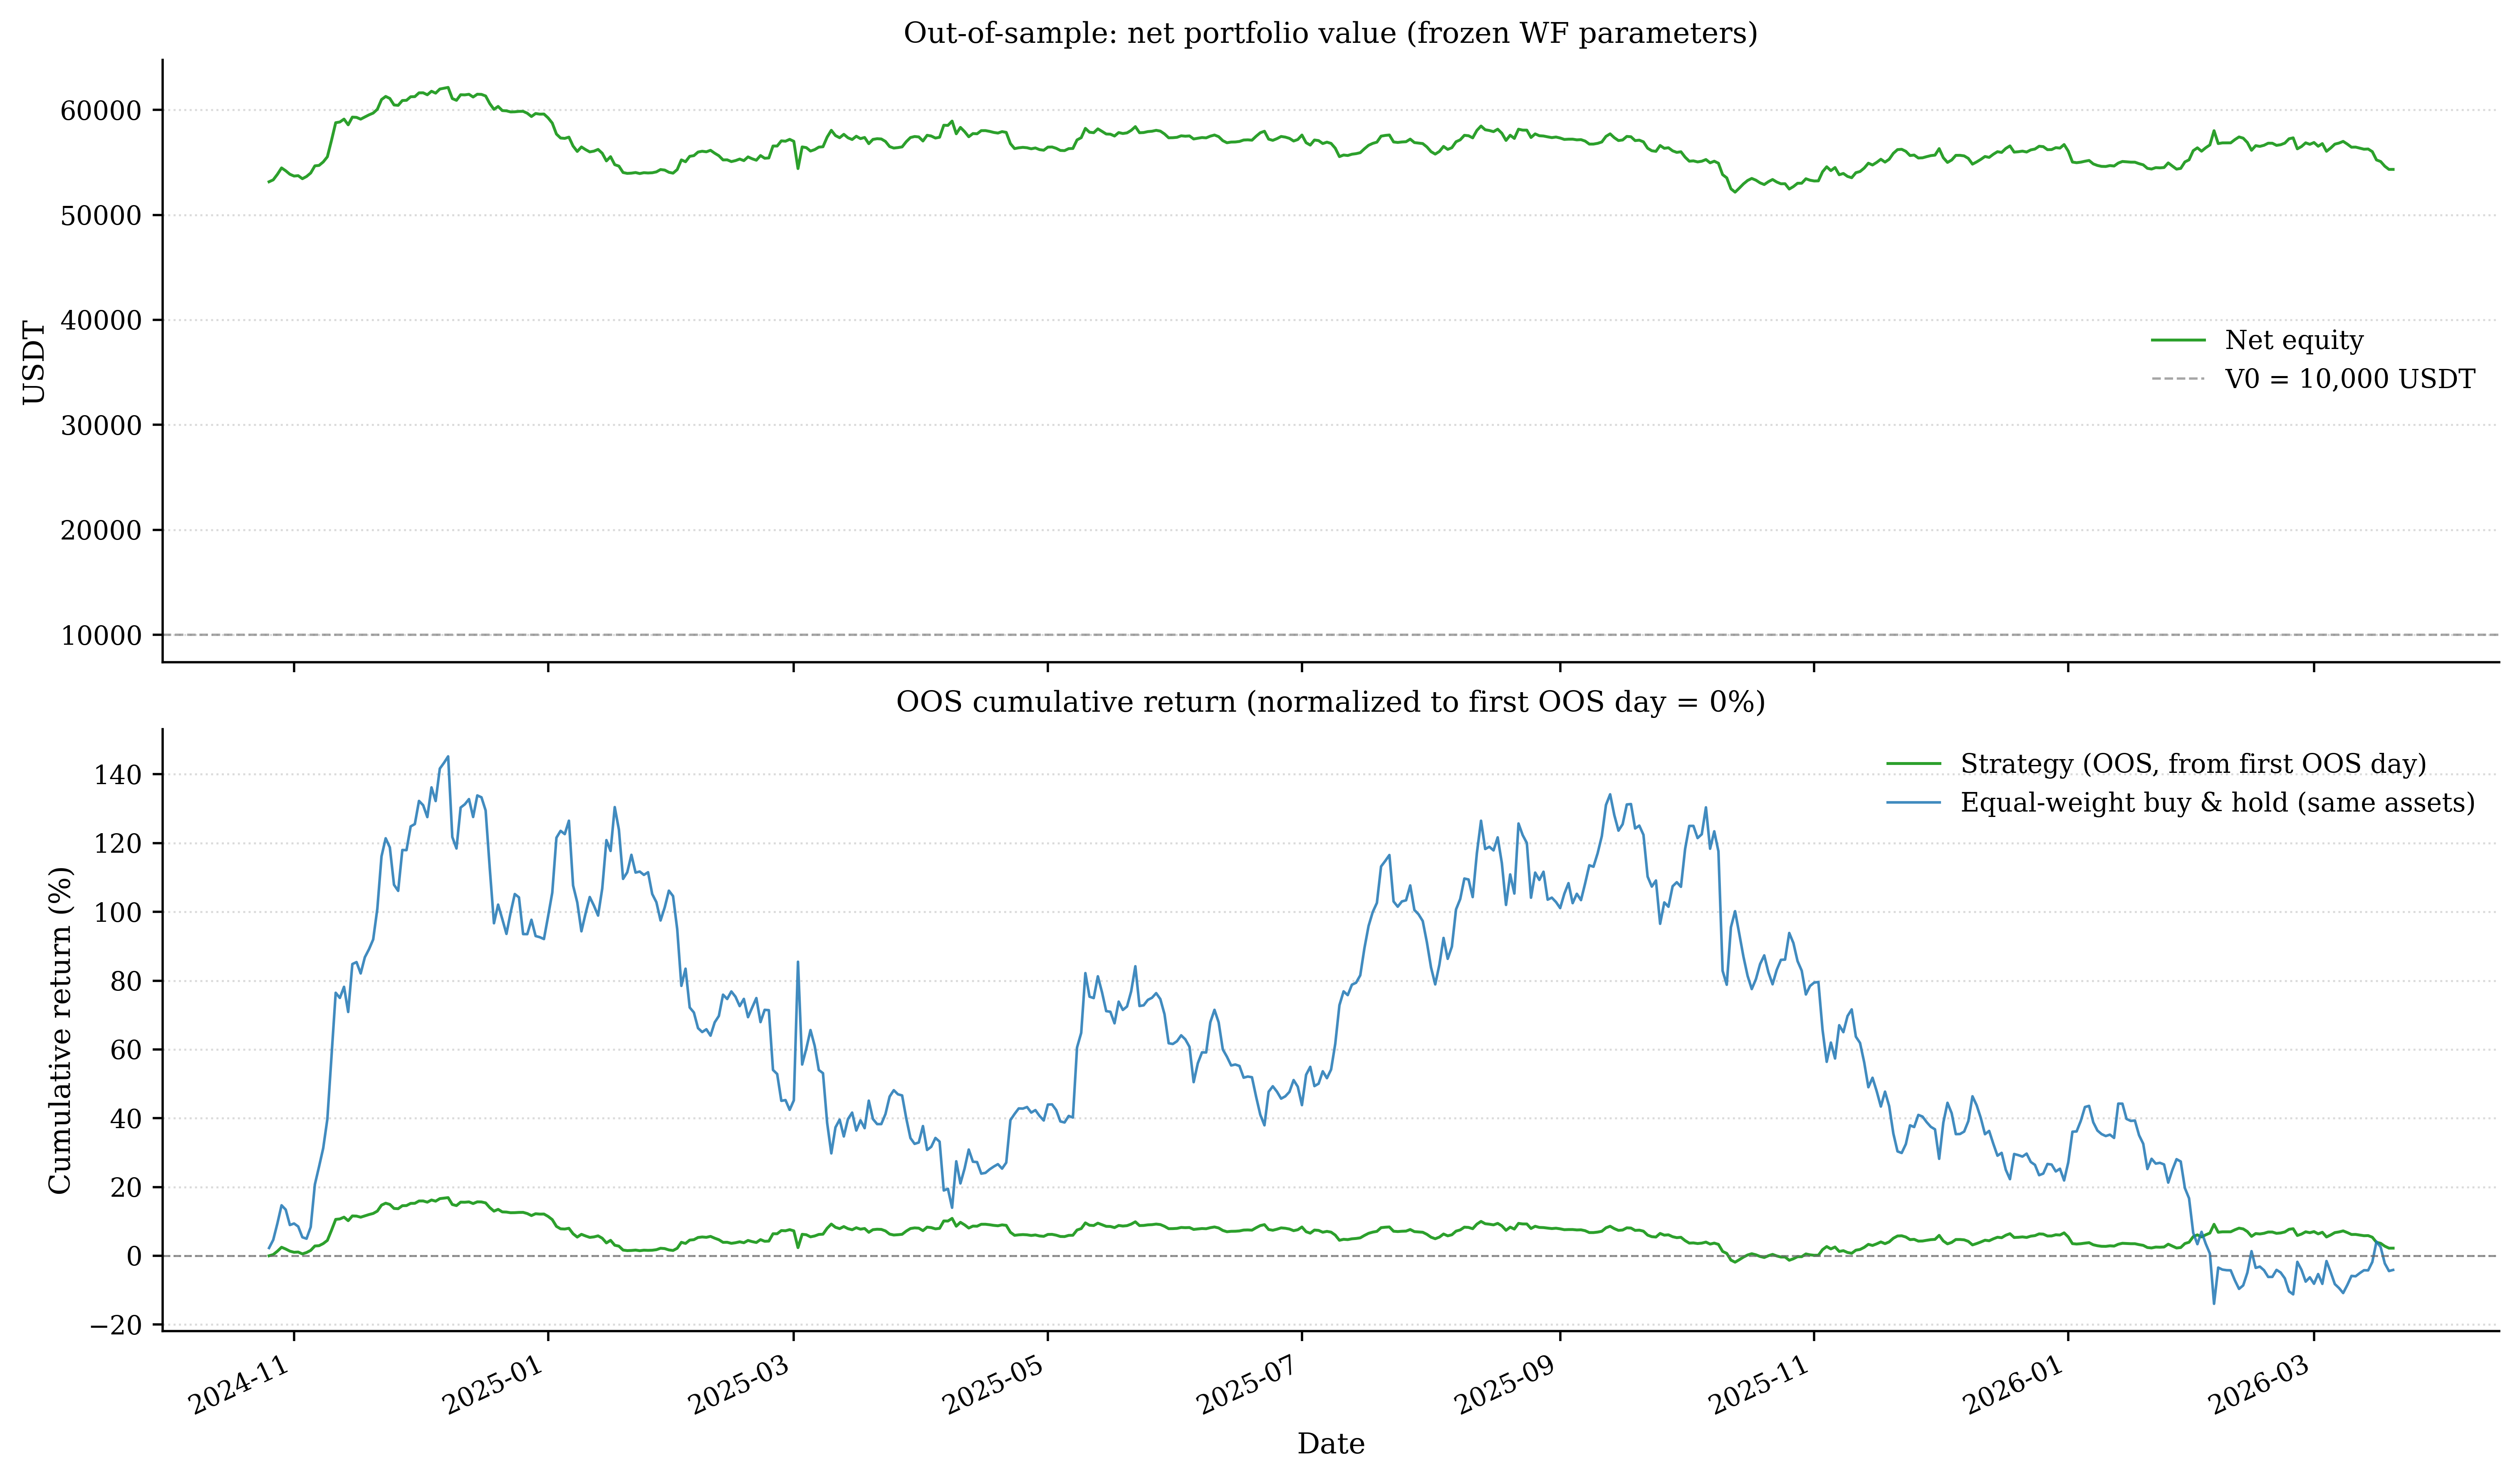

In [17]:
# --- OOS performance plot (holdout_index only) ---
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)

eq_oos_plot = net_pv_h.reindex(holdout_index).dropna()
if len(eq_oos_plot) < 2:
    print("OOS plot skipped: need at least 2 days with valid net equity on holdout.")
else:
    cum_ret_oos = eq_oos_plot / eq_oos_plot.iloc[0] - 1.0
    r_h = asset_panel["close"].pct_change().reindex(holdout_index).dropna(how="any")
    ew_daily = r_h.mean(axis=1).reindex(eq_oos_plot.index).fillna(0.0)
    cum_ew_bh = (1.0 + ew_daily).cumprod() - 1.0

    fig_oos, axes_oos = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
    axes_oos[0].plot(eq_oos_plot.index, eq_oos_plot, color="tab:green", linewidth=1.0, label="Net equity")
    axes_oos[0].axhline(V0_WF, color="0.5", linestyle="--", linewidth=0.8, alpha=0.7, label=f"V0 = {V0_WF:,.0f} USDT")
    axes_oos[0].set_ylabel("USDT")
    axes_oos[0].set_title("Out-of-sample: net portfolio value (frozen WF parameters)")
    axes_oos[0].legend(loc="best", frameon=False)
    axes_oos[0].grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)
    axes_oos[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    axes_oos[1].plot(cum_ret_oos.index, cum_ret_oos * 100.0, color="tab:green", linewidth=1.0, label="Strategy (OOS, from first OOS day)")
    axes_oos[1].plot(cum_ew_bh.index, cum_ew_bh * 100.0, color="tab:blue", linewidth=0.9, alpha=0.85, label="Equal-weight buy & hold (same assets)")
    axes_oos[1].axhline(0.0, color="0.4", linewidth=0.7, linestyle="--", alpha=0.7)
    axes_oos[1].set_ylabel("Cumulative return (%)")
    axes_oos[1].set_xlabel("Date")
    axes_oos[1].set_title("OOS cumulative return (normalized to first OOS day = 0%)")
    axes_oos[1].legend(loc="best", frameon=False)
    axes_oos[1].grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)
    axes_oos[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(axes_oos[1].xaxis.get_majorticklabels(), rotation=25, ha="right")

    fig_oos.savefig(out_dir / "oos_performance.png", bbox_inches="tight", dpi=150)
    fig_oos.savefig(out_dir / "oos_performance.pdf", bbox_inches="tight")
    plt.show()
